# Examining Patterns in Federal Transactions in Different Sized Regions using Apriori

The first part of this data mining project aims to answer the question: "What combinations of awarding agencies, recipients, and funding types frequently co-occur in different regions of Georgia?" It examines records of every federal transaction made by the Federal government to Georgia, with a threshold of $20,000,000, within fiscal year 2025. The goal is to perform apriori to find out what different regions of Georgia (divided by population range) tend to receive the most in federal spending. 

# EDA Process and Preprocessing

### 1. Data Loading
The data used for this exploration comes from "U.S.A Spending.gov", a website that keeps track of every transaction made to every state. Filters can be used to sort out different states, fiscal years, minimum amounts, etc. This data filters out every transaction made to Geoorgia in the year 2025, with a minimum value of $20,000,000.

Below is the link to the website which the csv file came from. All the filters used should be in place.

Link: https://www.usaspending.gov/search?hash=c2c3c2289128b5b40f0f64f62e847828

Upon downloading the data, it is split into two csv files: one for contracts and one for assistance awards. Contracts are treated as the government spending money on a good or service for their benefit, while Grants are awarded by the government to the recipient for various purpouses, such as research. Both have their own parameters and stored data types, so the split makes sense. 

In [2]:
import pandas as pd
import numpy as np
import statistics 
import matplotlib.pyplot as plt

#Loading the raw data from the "assistance" set of transactions. 
df = pd.read_csv(r"C:\Users\Fnsp1\Downloads\PrimeAwardSummariesAndSubawards_2026-02-12_H23M45S15539241\Assistance_PrimeAwardSummaries_ORIGINAL.csv")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df.head()

,assistance_award_unique_key,award_id_fain,award_id_uri,sai_number,disaster_emergency_fund_codes,outlayed_amount_from_COVID-19_supplementals,obligated_amount_from_COVID-19_supplementals,outlayed_amount_from_IIJA_supplemental,obligated_amount_from_IIJA_supplemental,award_latest_action_date,award_latest_action_date_fiscal_year,total_obligated_amount,total_outlayed_amount,indirect_cost_federal_share_amount,total_non_federal_funding_amount,total_funding_amount,total_face_value_of_loan,total_loan_subsidy_cost,award_base_action_date,award_base_action_date_fiscal_year,period_of_performance_start_date,period_of_performance_current_end_date,awarding_agency_code,awarding_agency_name,awarding_sub_agency_code,awarding_sub_agency_name,awarding_office_code,awarding_office_name,funding_agency_code,funding_agency_name,funding_sub_agency_code,funding_sub_agency_name,funding_office_code,funding_office_name,treasury_accounts_funding_this_award,federal_accounts_funding_this_award,object_classes_funding_this_award,program_activities_funding_this_award,recipient_uei,recipient_duns,recipient_name,recipient_name_raw,recipient_parent_uei,recipient_parent_duns,recipient_parent_name,recipient_country_code,recipient_country_name,recipient_address_line_1,recipient_address_line_2,recipient_city_code,recipient_city_name,prime_award_summary_recipient_county_fips_code,recipient_county_name,prime_award_summary_recipient_state_fips_code,recipient_state_code,recipient_state_name,recipient_zip_code,recipient_zip_last_4_code,prime_award_summary_recipient_cd_original,prime_award_summary_recipient_cd_current,recipient_foreign_city_name,recipient_foreign_province_name,recipient_foreign_postal_code,primary_place_of_performance_scope,primary_place_of_performance_country_code,primary_place_of_performance_country_name,primary_place_of_performance_code,primary_place_of_performance_city_name,prime_award_summary_place_of_performance_county_fips_code,primary_place_of_performance_county_name,prime_award_summary_place_of_performance_state_fips_code,primary_place_of_performance_state_name,primary_place_of_performance_zip_4,prime_award_summary_place_of_performance_cd_original,prime_award_summary_place_of_performance_cd_current,primary_place_of_performance_foreign_location,cfda_numbers_and_titles,funding_opportunity_number,funding_opportunity_goals_text,assistance_type_code,assistance_type_description,prime_award_base_transaction_description,business_funds_indicator_code,business_funds_indicator_description,business_types_code,business_types_description,record_type_code,record_type_description,highly_compensated_officer_1_name,highly_compensated_officer_1_amount,highly_compensated_officer_2_name,highly_compensated_officer_2_amount,highly_compensated_officer_3_name,highly_compensated_officer_3_amount,highly_compensated_officer_4_name,highly_compensated_officer_4_amount,highly_compensated_officer_5_name,highly_compensated_officer_5_amount,usaspending_permalink,last_modified_date
0,ASST_AGG_2800202410310000006815_028,NaN,2800202410310000006815,SAIEXEMPT,Q: Not Designated Nonemergency/Emergency/Disas...,NaN,NaN,NaN,NaN,2024-10-31,2025,85752367.0,85752367.0,NaN,NaN,85752367.0,0.0,0.0,2024-10-31,2025,NaN,NaN,28,Social Security Administration,2800,Social Security Administration,283227,SSA Office of Financial Policy,28.0,Social Security Administration,2800,Social Security Administration,283227,SSA Office of Financial Policy,028-028-X-8006-000,028-8006,42.0: Insurance claims and indemnities,0001: FEDERAL OLD-AGE AND SURVIVORS INSURANCE ...,NaN,NaN,MULTIPLE RECIPIENTS,MULTIPLE RECIPIENTS,NaN,NaN,NaN,USA,UNITED STATES,NaN,NaN,NaN,NaN,13051,CHATHAM,13,GA,GEORGIA,NaN,NaN,GA-01,GA-01,NaN,NaN,NaN,COUNTY-WIDE,USA,UNITED STATES,GA**051,NaN,13051.0,CHATHAM,13,GEORGIA,NaN,GA-01,GA-01,NaN,96.002: SOCIAL SECURITY RETIREMENT INSURANCE,NaN,NaN,10,DIRECT PAYMENT WITH UNRESTRICTED USE (RETIREME...,AGGREGATE RETIREMENT INSURANCE (RI) BENEFITS,NON,NOT RECOVERY ACT,P,INDIVIDUAL,1,AGGREGATE RECORD,NaN,NaN,Na

In [3]:
#Loading the raw data from the "assistance" set of transactions.
df2 = pd.read_csv(r"C:\Users\Fnsp1\Downloads\PrimeAwardSummariesAndSubawards_2026-02-12_H23M45S15539241\Contracts_PrimeAwardSummaries_ORIGINAL.csv")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df2.head()

,contract_award_unique_key,award_id_piid,parent_award_agency_id,parent_award_agency_name,parent_award_id_piid,disaster_emergency_fund_codes,outlayed_amount_from_COVID-19_supplementals,obligated_amount_from_COVID-19_supplementals,outlayed_amount_from_IIJA_supplemental,obligated_amount_from_IIJA_supplemental,total_obligated_amount,total_outlayed_amount,current_total_value_of_award,potential_total_value_of_award,award_base_action_date,award_base_action_date_fiscal_year,award_latest_action_date,award_latest_action_date_fiscal_year,period_of_performance_start_date,period_of_performance_current_end_date,period_of_performance_potential_end_date,ordering_period_end_date,solicitation_date,awarding_agency_code,awarding_agency_name,awarding_sub_agency_code,awarding_sub_agency_name,awarding_office_code,awarding_office_name,funding_agency_code,funding_agency_name,funding_sub_agency_code,funding_sub_agency_name,funding_office_code,funding_office_name,treasury_accounts_funding_this_award,federal_accounts_funding_this_award,object_classes_funding_this_award,program_activities_funding_this_award,foreign_funding,foreign_funding_description,sam_exception,sam_exception_description,recipient_uei,recipient_duns,recipient_name,recipient_name_raw,recipient_doing_business_as_name,cage_code,recipient_parent_uei,recipient_parent_duns,recipient_parent_name,recipient_parent_name_raw,recipient_country_code,recipient_country_name,recipient_address_line_1,recipient_address_line_2,recipient_city_name,prime_award_summary_recipient_county_fips_code,recipient_county_name,prime_award_summary_recipient_state_fips_code,recipient_state_code,recipient_state_name,recipient_zip_4_code,prime_award_summary_recipient_cd_original,prime_award_summary_recipient_cd_current,recipient_phone_number,recipient_fax_number,primary_place_of_performance_country_code,primary_place_of_performance_country_name,primary_place_of_performance_city_name,prime_award_summary_place_of_performance_county_fips_code,primary_place_of_performance_county_name,prime_award_summary_place_of_performance_state_fips_code,primary_place_of_performance_state_code,primary_place_of_performance_state_name,primary_place_of_performance_zip_4,prime_award_summary_place_of_performance_cd_original,prime_award_summary_place_of_performance_cd_current,award_or_idv_flag,award_type_code,award_type,idv_type_code,idv_type,multiple_or_single_award_idv_code,multiple_or_single_award_idv,type_of_idc_code,type_of_idc,type_of_contract_pricing_code,type_of_contract_pricing,prime_award_base_transaction_description,solicitation_identifier,number_of_actions,inherently_governmental_functions,inherently_governmental_functions_description,product_or_service_code,product_or_service_code_description,contract_bundling_code,contract_bundling,dod_claimant_program_code,dod_claimant_program_description,naics_code,naics_description,recovered_materials_sustainability_code,recovered_materials_sustainability,domestic_or_foreign_entity_code,domestic_or_foreign_entity,dod_acquisition_program_code,dod_acquisition_program_description,information_technology_commercial_item_category_code,information_technology_commercial_item_category,epa_designated_product_code,epa_designated_product,country_of_product_or_service_origin_code,country_of_product_or_service_origin,place_of_manufacture_code,place_of_manufacture,subcontracting_plan_code,subcontracting_plan,extent_competed_code,extent_competed,solicitation_procedures_code,solicitation_procedures,type_of_set_aside_code,type_of_set_aside,evaluated_preference_code,evaluated_preference,research_code,research,fair_opportunity_limited_sources_code,fair_opportunity_limited_sources,other_than_full_and_open_competition_code,other_than_full_and_open_competition,number_of_offers_received,commercial_item_acquisition_procedures_code,commercial_item_acquisition_procedures,small_business_competitiveness_demonstration_program,simplified_procedures_for_certain_commercial_items_code,simplified_procedures_for_certain_commercial_

### 2. Checking Quality
The first step to examining the data is to get an idea of the differences between the columns of each set of data. To do this, I am checking for both duplicate ID values and missing data in each set. By doing this, I can both check the initital quality of the data itself, and compare both sets of columns through a manageable list.

In [ ]:
#Command to check the number of null values in each column. Also allows for easy examination of what each column represents.
df.isna().sum()

assistance_award_unique_key                                     0
award_id_fain                                                 675
award_id_uri                                                  159
sai_number                                                    234
disaster_emergency_fund_codes                                 119
outlayed_amount_from_COVID-19_supplementals                  1001
obligated_amount_from_COVID-19_supplementals                 1000
outlayed_amount_from_IIJA_supplemental                       1034
obligated_amount_from_IIJA_supplemental                      1023
award_latest_action_date                                        0
award_latest_action_date_fiscal_year                            0
total_obligated_amount                                          0
total_outlayed_amount                                         119
indirect_cost_federal_share_amount                            743
total_non_federal_funding_amount                              731
total_fund

In [ ]:
#Command to check the number of null values in each column. Also allows for easy examination of what each column represents.
df2.isna().sum()

contract_award_unique_key                                       0
award_id_piid                                                   0
parent_award_agency_id                                        137
parent_award_agency_name                                      137
parent_award_id_piid                                          137
disaster_emergency_fund_codes                                 138
outlayed_amount_from_COVID-19_supplementals                   340
obligated_amount_from_COVID-19_supplementals                  337
outlayed_amount_from_IIJA_supplemental                        401
obligated_amount_from_IIJA_supplemental                       401
total_obligated_amount                                          0
total_outlayed_amount                                         135
current_total_value_of_award                                    0
potential_total_value_of_award                                  0
award_base_action_date                                          0
award_base

Before going further, the datasets will be manually combined into one csv file. While contracts and assistance awards work under different names and categories, they can be matched up with each other. Furthermore, the information from both data sets supports the discovery question, since it includes information related to the agency, the recipient, and the type and terms of the transaction. Further data can be extracted, such as disaster funding, to explain any odd transactions that may appear.

Based on the proposed question and process from M1, the necessary columns will be: 

-Total Obligated Amount: The total amount of money the transaction is listed for. This will be used in this mining to examine anoamly transactions to determine their relevance in the context of frequent combinations.

-Awarding Agency Name: The name of the government agency which the transaction is coming from.

-Recipient Name: The name of the individual or business which the transaction is directed to.

-Recipient County Name: The county in Georgia which the recipient recieved the transaction in.

-Assistance Type Description: The category of federal spending the transaction falls under (e.g. Delivery Order).

In addition to these columns, Award ID, Disaster Emergency Fund Codes, Agency Sub Name, address lines, City Name, and the link to the individual transaction will be kept to add further context for each transaction. This will be mostly helpful in examining common trends amongst outlier values. When combining the data sets, the columns will take the name of the data found in the "Assistance_Awards" table.

Below is the first five transactions listed in the combined data set of all transactions.

In [5]:
#Loading and examining the combined matrix of all assistance and contract transactions
dfall = pd.read_csv(r"C:\Users\Fnsp1\Downloads\PrimeAwardSummariesAndSubawards_2026-02-12_H23M45S15539241\All Awards.csv")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
dfall.head()

,award_id_fain,disaster_emergency_fund_codes,obligated_amount_from_COVID-19_supplementals,obligated_amount_from_IIJA_supplemental,total_obligated_amount,awarding_agency_name,awarding_sub_agency_name,recipient_name,recipient_address_line_1,recipient_address_line_2,recipient_city_name,recipient_county_name,assistance_type_description,prime_award_base_transaction_description,business_types_description,usaspending_permalink
0,NaN,Q: Not Designated Nonemergency/Emergency/Disas...,NaN,NaN,85752367.0,Social Security Administration,Social Security Administration,MULTIPLE RECIPIENTS,NaN,NaN,NaN,CHATHAM,DIRECT PAYMENT WITH UNRESTRICTED USE (RETIREME...,AGGREGATE RETIREMENT INSURANCE (RI) BENEFITS,INDIVIDUAL,https://www.usaspending.gov/award/ASST_AGG_280...
1,NaN,Q: Not Designated Nonemergency/Emergency/Disas...,NaN,NaN,33804074.0,Social Security Administration,Social Security Administration,MULTIPLE RECIPIENTS,NaN,NaN,NaN,GLYNN,DIRECT PAYMENT WITH UNRESTRICTED USE (RETIREME...,AGGREGATE RETIREMENT INSURANCE (RI) BENEFITS,INDIVIDUAL,https://www.usaspending.gov/award/ASST_AGG_280...
2,NaN,Q: Not Designated Nonemergency/Emergency/Disas...,NaN,NaN,25588351.0,Social Security Administration,Social Security Administration,MULTIPLE RECIPIENTS,NaN,NaN,NaN,BIBB,DIRECT PAYMENT WITH UNRESTRICTED USE (RETIREME...,AGGREGATE RETIREMENT INSURANCE (RI) BENEFITS,INDIVIDUAL,https://www.usaspending.gov/award/ASST_AGG_280...
3,NaN,Q: Not Designated Nonemergency/Emergency/Disas...,NaN,NaN,22692773.0,Social Security Administration,Social Security Administration,MULTIPLE RECIPIENTS,NaN,NaN,NaN,DOUGHERTY,DIRECT PAYMENT WITH UNRESTRICTED USE (RETIREME...,AGGREGATE RETIREMENT INSURANCE (RI) BENEFITS,INDIVIDUAL,https://www.usaspending.gov/award/ASST_AGG_280...
4,NaN,Q: Not Designated Nonemergency/Emergency/Disas...,NaN,NaN,38196471.0,Social Security Administration,Social Security Administration,MULTIPLE RECIPIENTS,NaN,NaN,NaN,MUSCOGEE,DIRECT PAYMENT WITH UNRESTRICTED USE (RETIREME...,AGGREGATE RETIREMENT INSURANCE (RI) BENEFITS,INDIVIDUAL,https://www.usaspending.gov/award/ASST_AGG_280...


Now that the data is consolidated into one file, it will be checked again for duplicates and null values. When checking for duplicates, the ID column will be combed for every like value.

In [ ]:
#Checking the overall information of the data
dfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1483 entries, 0 to 1482
Data columns (total 16 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   award_id_fain                                 808 non-null    object 
 1   disaster_emergency_fund_codes                 1226 non-null   object 
 2   obligated_amount_from_COVID-19_supplementals  146 non-null    float64
 3   obligated_amount_from_IIJA_supplemental       59 non-null     float64
 4   total_obligated_amount                        1483 non-null   float64
 5   awarding_agency_name                          1483 non-null   object 
 6   awarding_sub_agency_name                      1483 non-null   object 
 7   recipient_name                                1483 non-null   object 
 8   recipient_address_line_1                      808 non-null    object 
 9   recipient_address_line_2                      121 non-null    o

In [ ]:
#Checking the number of null values in each column
dfall.isna().sum()

award_id_fain                                    675
disaster_emergency_fund_codes                    257
obligated_amount_from_COVID-19_supplementals    1337
obligated_amount_from_IIJA_supplemental         1424
total_obligated_amount                             0
awarding_agency_name                               0
awarding_sub_agency_name                           0
recipient_name                                     0
recipient_address_line_1                         675
recipient_address_line_2                        1362
recipient_city_name                              675
recipient_county_name                              1
assistance_type_description                        0
prime_award_base_transaction_description           1
business_types_description                        11
usaspending_permalink                              0
dtype: int64

From here we can see that almost every major column needed has no null values. Some columns have null values, but they all have reasons for them:

--All null ID values are found on transactions labeled as "MULTIPLE RECIPIENTS", and US Spending makes it clear that programs, such as Social Security where individual recipients collect their funds directly from the agency in their mailbox, prohibit information from those individuals to be revealed. This is not a big deal, since all of the county names are still present. 

--Not every transaction is made to answer to an emergency disaster, hence why there are many null values related to disaster emergency codes and supplementals. Null values here are still relevant information.

--There are several missing address lines, which also tie back to the amount of "MULTIPLE RECIPIENT" transactions.

In [ ]:
#Lists every transaction by row number and flags each duplicate value
dfall['award_id_fain'].duplicated()

0       False
1        True
2        True
3        True
4        True
5        True
6        True
7        True
8        True
9        True
10       True
11       True
12       True
13       True
14       True
15       True
16       True
17       True
18       True
19       True
20       True
21       True
22       True
23       True
24       True
25       True
26       True
27       True
28       True
29       True
30       True
31       True
32       True
33       True
34       True
35       True
36       True
37       True
38       True
39       True
40       True
41       True
42       True
43       True
44       True
45       True
46       True
47       True
48       True
49       True
50       True
51       True
52       True
53       True
54       True
55       True
56       True
57       True
58       True
59       True
60       True
61       True
62       True
63       True
64       True
65       True
66       True
67       True
68       True
69       True
70       True
71    

In [ ]:
#calculates and prints the total number of duplicate values in the ID column
df3['award_id_fain'].duplicated().sum()

np.int64(675)

Once again, we see that the amount of duplicate values is equal to the amount of null values, which all relate to transactions with "MULTIPLE RECIPIENTS". This is evident in the list above, which checks for duplicate values and marks "True" on every transaction ID with multiple recipients. Therefore, we can see there are actually no duplicate transactions listed in the data.

### 3. Visuals and Preprocessing

Now that both sets of data are merged, and we have confirmed the quality of the data, they need to be prepared for data mining. Every piece of data we need is in the set, however the set still needs to include the population sizes of the county that the transaction is marked for. 

First, the actual population size needs to be recorded. Before this happens, I want to observe the amount of unique counties, and how frequently they show up so that I know there are enough unique counties to examine. To do this, a bar chart will be generated to visualize this spread.

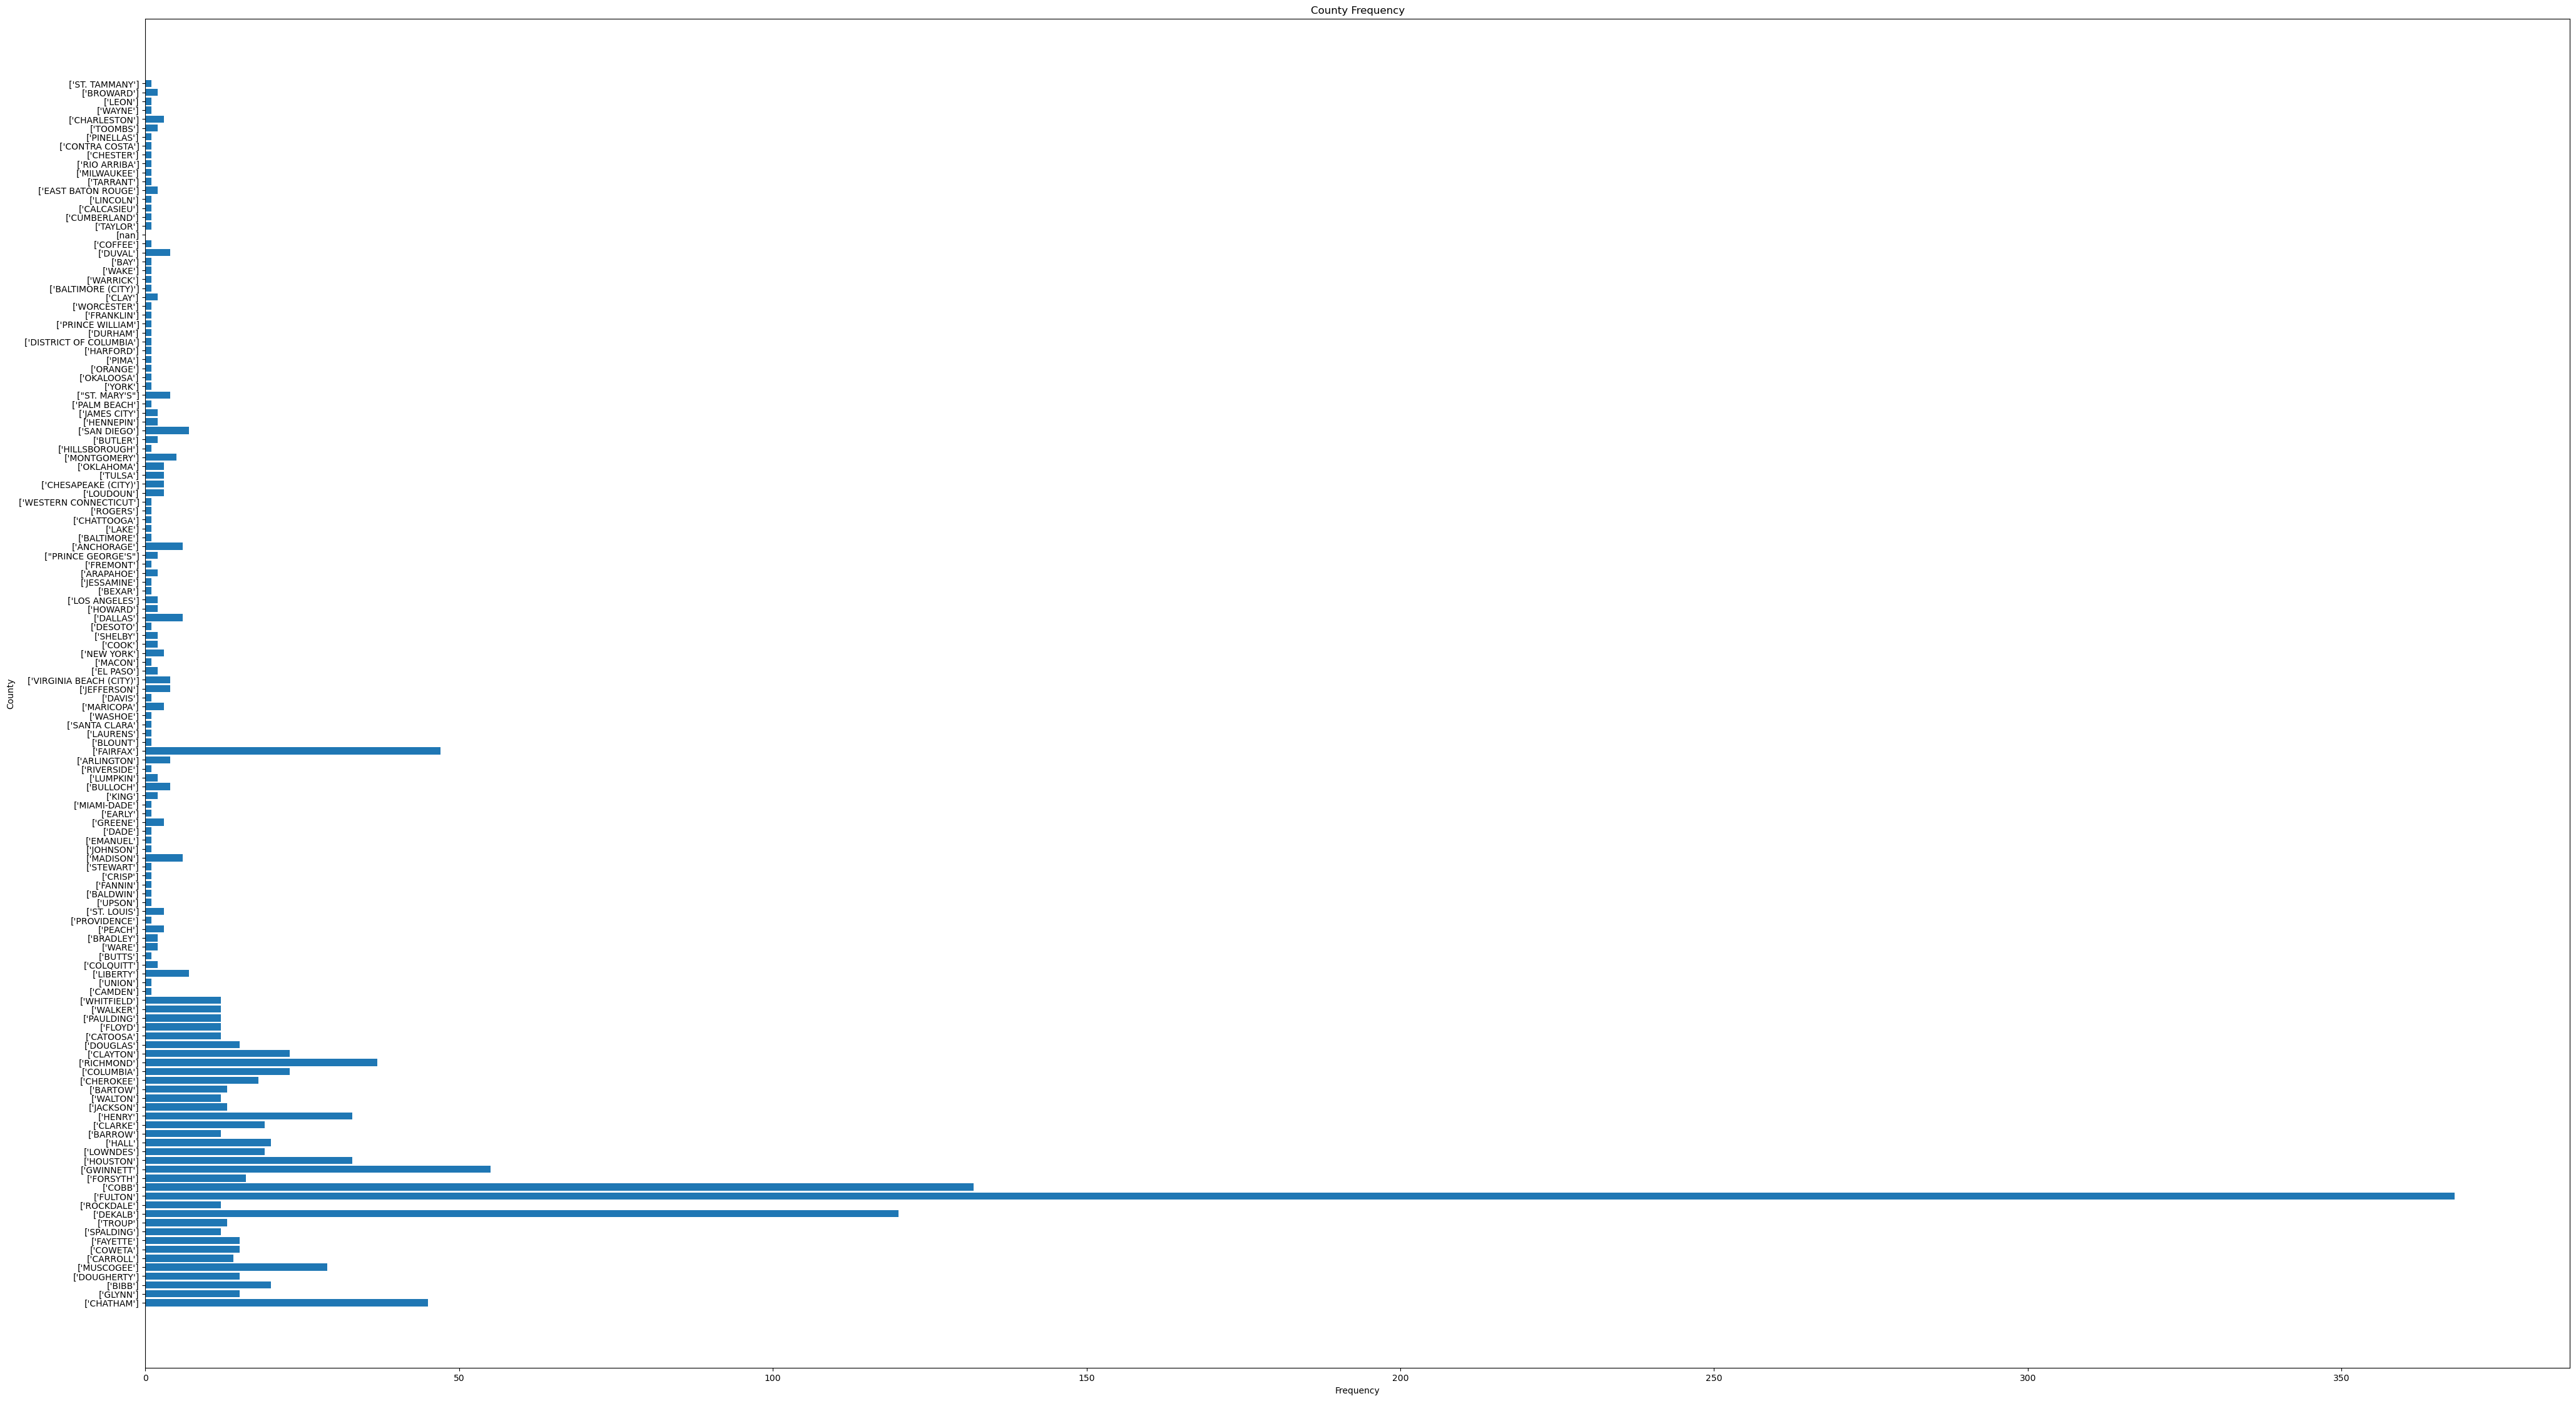

In [ ]:
import pandas as pd
dftemp = pd.read_csv("All Awards.csv", usecols=['recipient_county_name'])
data = np.array(dftemp)

countyName = []#Represents as list of each unique county
counts = []#Represents the number of times each county shows up
currentCount = 0
for item in data:#Iterating through the county name column
    currentCount = 0
    if item not in countyName:#checks if the county is present in the countyName list. If it is not, it adds it to the list, then checks the list again for every instance of that county.
        countyName.append(str(item))
        for name in data:
            if name == item:
                currentCount += 1
        counts.append(currentCount)
        
#displays the bar chart of every county and their frequency.
fig = plt.subplots(figsize =(50, 28))
plt.barh(countyName, counts)
plt.title('County Frequency')
plt.xlabel('Frequency')
plt.ylabel('County')
plt.show()

As expected, we can tell that urban areas, such as Fulton County, dominate the data. There is also a wide selection of smaller counties to choose from, which will all be binned into similar population sizes. The amount of transactions made from certain agencies to multiple rural areas should be similar to the amount of transactions made by one agency to Fulton or Dekalb, so frequent combinations will be present.

The chart reveals that there are 138 unique counties, however it also reveals that there are several counties recorded that are not from the state of Georgia. Luckily, the majority of these records have Georgia zip codes within their primary place of performance. Now, a new column will be added to record the population size of each county. The 2020 population census will be used for the official number, since this the latest and most accurate recoreded population. For those counties that are not from Georgia, the zip code from their primary place of performance will be examined, and the county that it shows up in will replace the current one recorded.

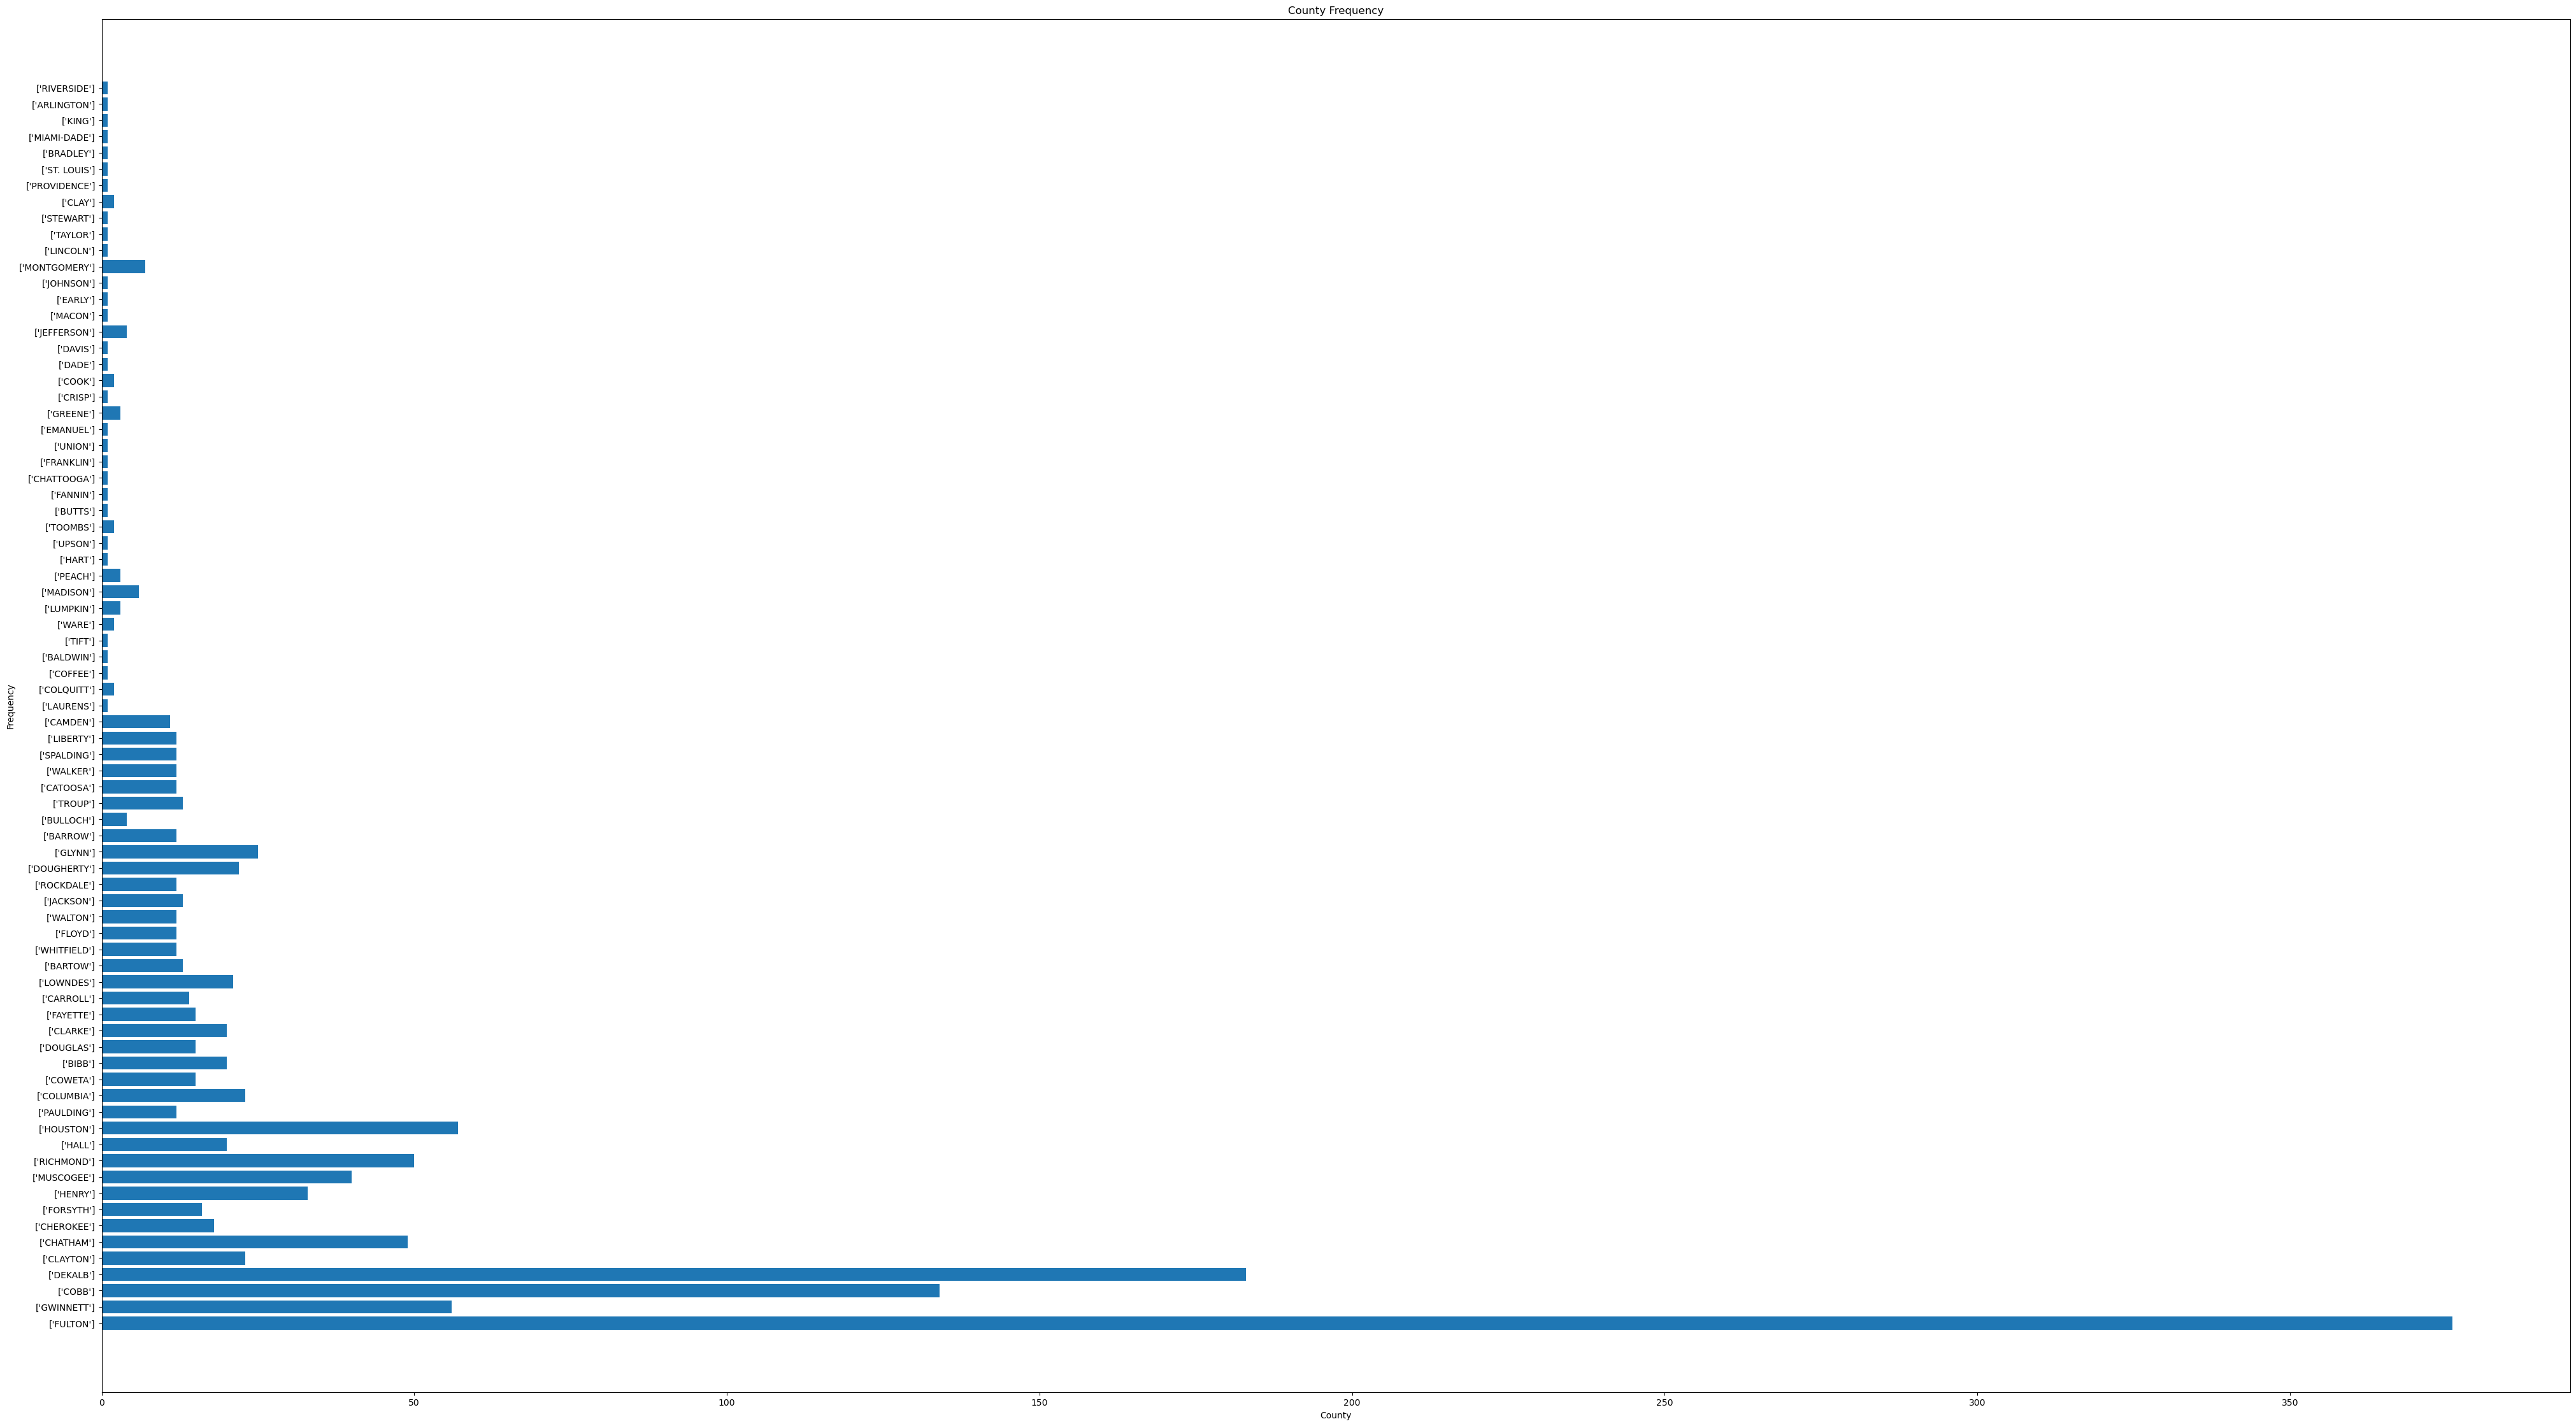

In [ ]:
import pandas as pd
dftemp = pd.read_csv("All Awards w CountySize Modded.csv", usecols=['recipient_county_name'])
data = np.array(dftemp)

countyName = []
counts = []
currentCount = 0
for item in data:
    currentCount = 0
    if item not in countyName:
        countyName.append(str(item))
        for name in data:
            if name == item:
                currentCount += 1
        counts.append(currentCount)
        
fig = plt.subplots(figsize =(50, 28))
plt.barh(countyName, counts)
plt.title('County Frequency')
plt.xlabel('Frequency')
plt.ylabel('County')
plt.show()

After swapping out each non-Georgia county, the amount of counties significantly decreased. Now the data is left with 77 unique counties, which still leaves more than enough counties to examine. There also appeared to be 7 transactions that did not have a zip code under primary place of performance. Since we only care about Georgia recipients, and with no way of tracking exactly where the Georgia recipient is based from, these 7 transactions will be deleted from the data. It is undesirable to replace them with an arbitrary location, and removing 7 transactions from the list of 1483 will not heavily affect the results of the algorithm. From here, the population sizes will be added.

After population sizes are added, we will use IQR to determine how much of the data is considered to be an outlier. A box and whisker plot will be used to visualize the spread of outliers.

mean: 
[1.06082734e+08]
median: 
[38196471.]
q3: 
65804710.0
q1: 
27342669.02


(-200000000.0, 200000000.0)

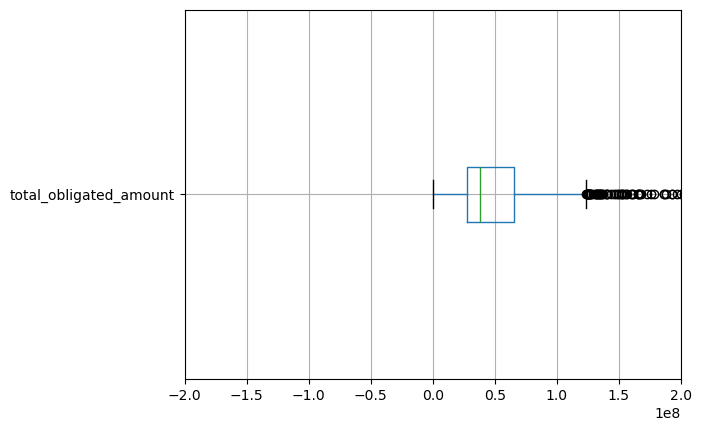

In [ ]:
#Using pre built python methods to display the IQR of the obligated amount column.
df4 = pd.read_csv("All Awards.csv", usecols=['total_obligated_amount'])
obl = np.array(df4)
mean = sum(obl)/len(obl)
print('mean: ')
print(mean)

med = statistics.median(obl) 
print('median: ')
print(med)

q3, q1 = np.percentile(obl, [75 ,25])
print('q3: ')
print(q3)
print('q1: ')
print(q1)

#Translates the column into a box and whisker plot.
fig = df4.boxplot(column=['total_obligated_amount'], vert=False)
fig.set_xlim([-200000000, 200000000])#Limit set to properly display the entire data set.

In [ ]:
#Checks each value for being an outlier, then prints the total number of outliers, and the ratio of outliers in the set.
outliers = 0
for amount in obl:
    if amount > q3:
        outliers += 1
outlierRatio = outliers / len(obl)
print('outliers: ')
print(outliers)
print('ratio: ')
print(outlierRatio)

outliers: 
371
ratio: 
0.25016857720836144


This visual represents the data spread of each obligation. Wer care about examining what transactions frequently occur in different regions, so if there are anomaly transactions left in the data, the support values for each combination will be skewed. However, the box and whisker plot reveals that the top 25% of the graph is being flagged as an outlier transaction, and mostly appear to be a gradual increase in dollar amounts. If these are gradual increases, then these transactions can still co-occur frequently. Despite this, the large mean value reveals the existence of oddly large transactions. 

It would be unwise to remove an entire fourth of the set, so to determine how much of these outliers we will keep, we must see if there is any point where the obligations take a huge leap in value. To further examine this, a bar chart will be used to visualize the spread of the transactions. A bar chart will be best here when working with over 1400 transactions. When sorted from smallest dollar amount to largest dollar amount, the bar graph will shape the increase in dollar amounts over all the transactions. Any large leaps in dollar amounts will be further examined.

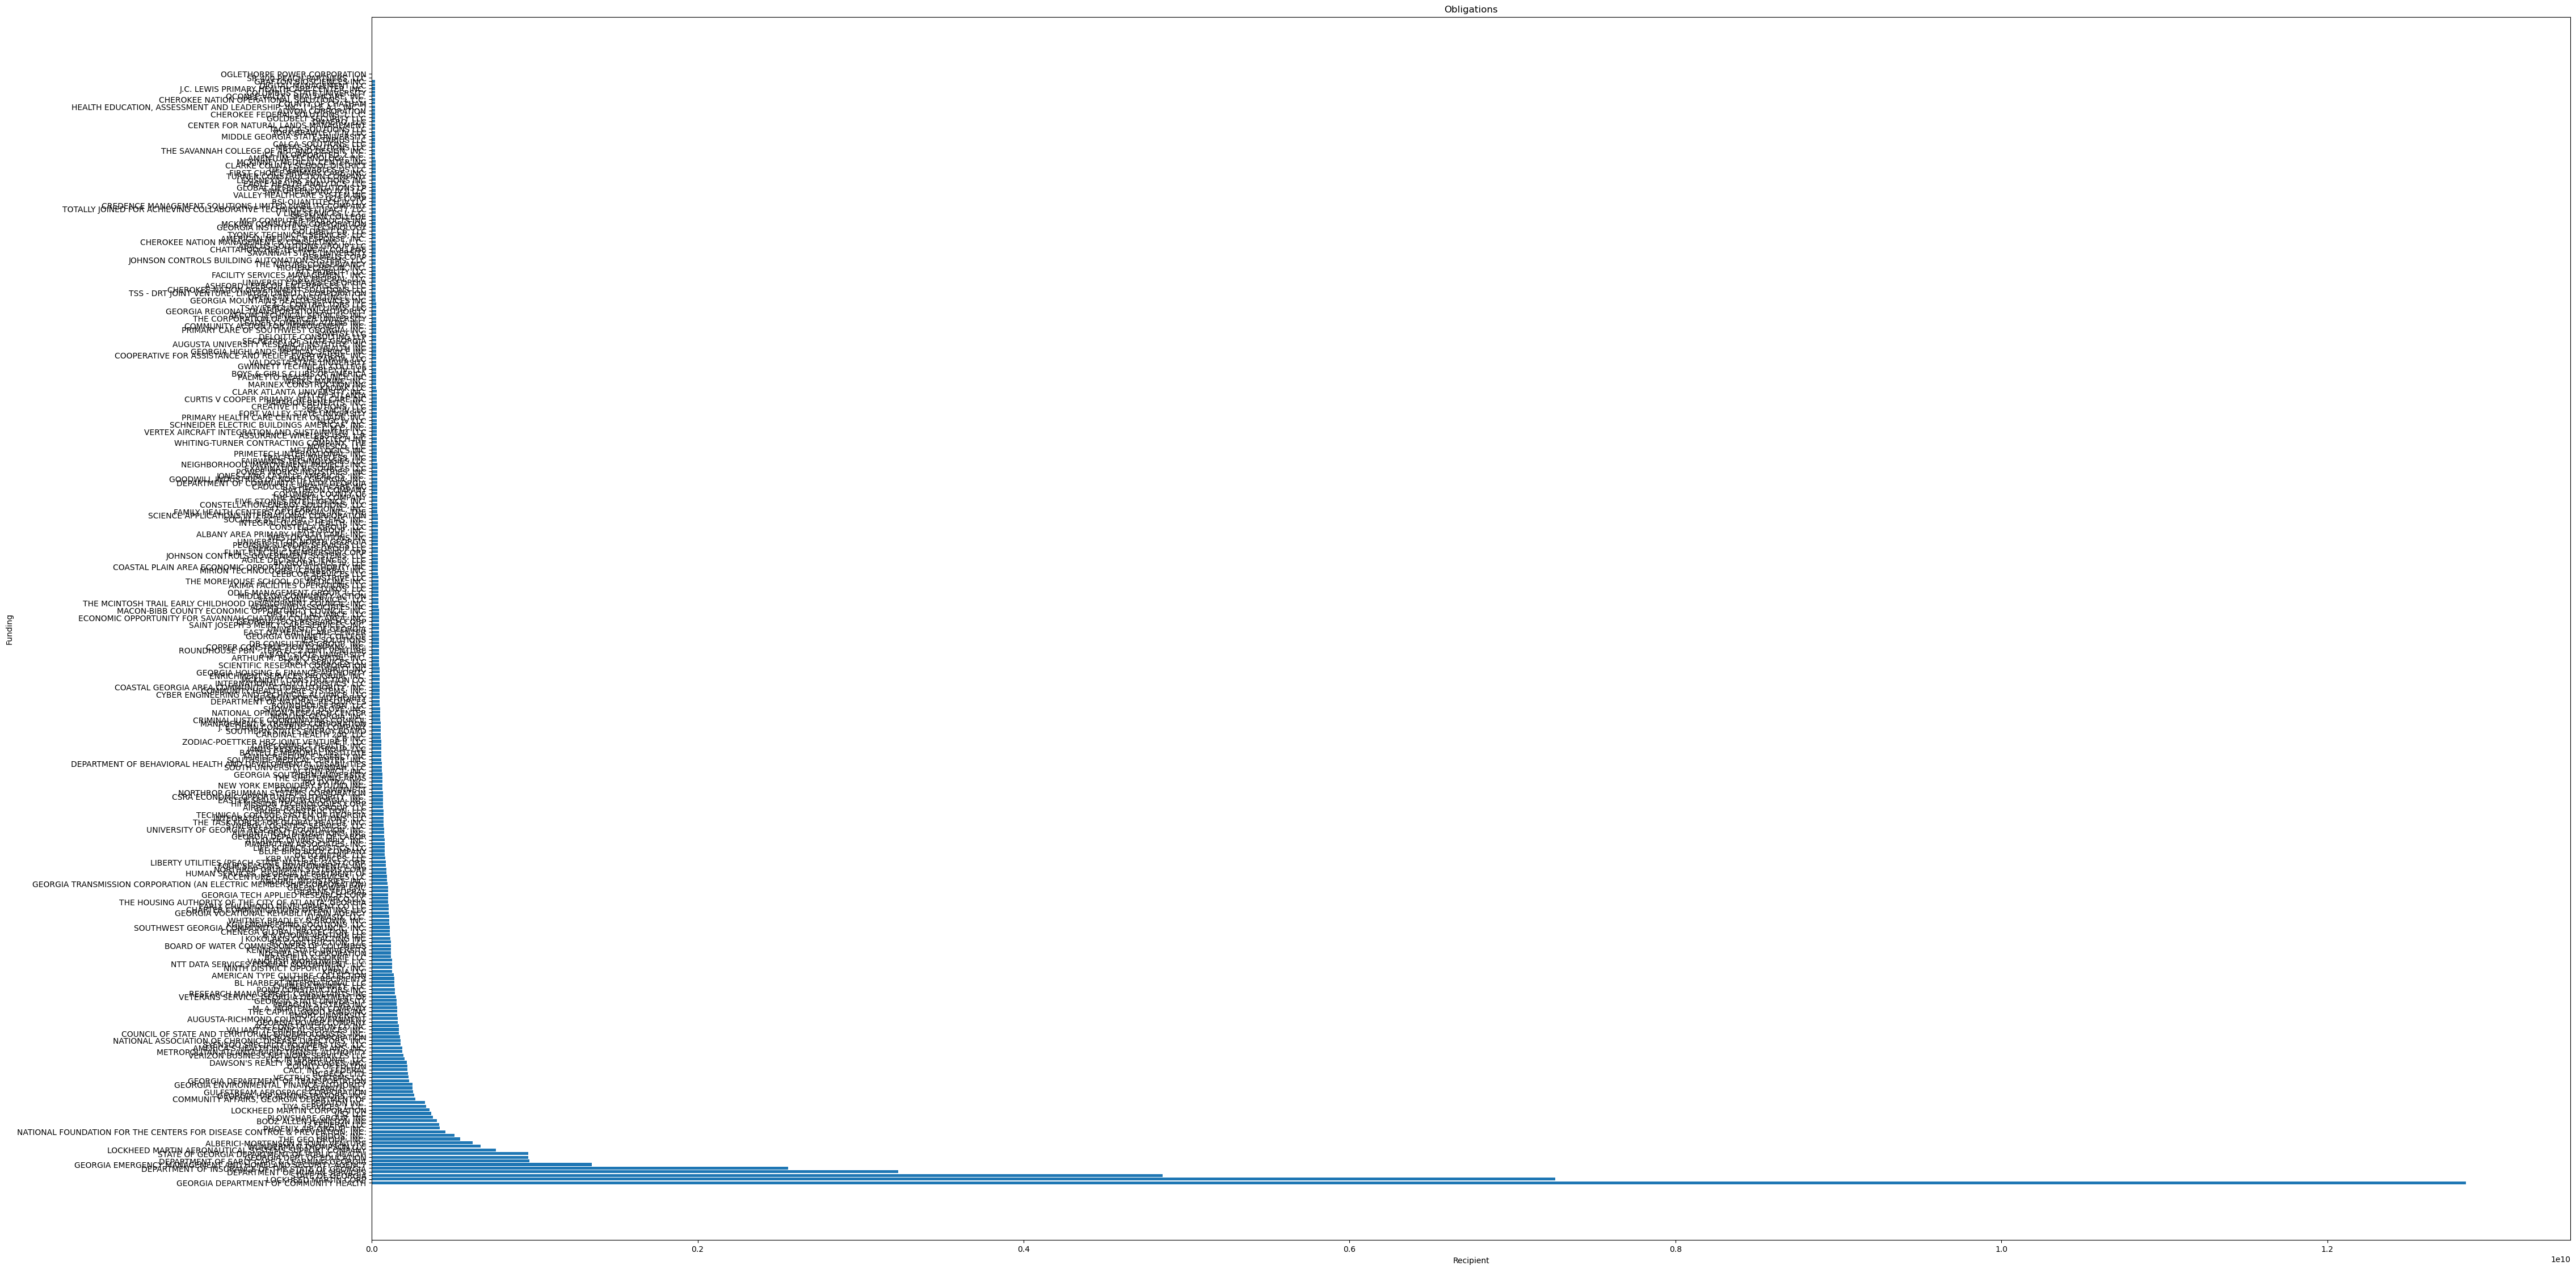

In [ ]:
#Displays a bar chart of every transaction by their recipient and obligated amount. The shape of the graph forms an easy to visualize size spread for the obligation amounts.
import pandas as pd
df = pd.read_csv("All Awards w CountySize.csv")
fig = plt.subplots(figsize =(50, 28))
plt.barh(df['recipient_name'],df['total_obligated_amount'])
plt.title('Obligations')
plt.xlabel('Funding')
plt.ylabel('Recipient')
plt.show()

The graph reveals that there is a spike in value between the fifth largest transaction (5934097112), to the fourth largest transaction (7261932654). These top four transactions do not appear to be anomaly transactions. The top two are MEDICAID transactions made to the Georgia Department of Community Health, and the third and fourth largest transactions are contracts made to Lockheed Martin Corp. Both of these combinations appear to frequently co-occur in the data. Since there appears to be a gradual increase in transaction amounts, and no anomaly data in the largest transactions, we will keep all of the data flagged as outliers in the set for examination. 

On the other end, there are three transactions with a total obligation of 0. These are the only three transactions marked as "loans" under the award type. Since these will be naturally pruned out, there is no need for the algorithm to waste effort on these transactions, and thus they will be removed from the dataset.

# Data Transforming

After examining each county and inserting their population sizes according to the 2020 U.S. Census in the preprocessing phase, another new column will be added to distribute each population into a bin representing a size ratio. Since we care about frequently occuring sets of data amongst different county sizes, this is the best way of comparing sizes as a collective. First, we will use a histogram to visualize the frequency spread of each size.

Text(0, 0.5, 'Frequency')

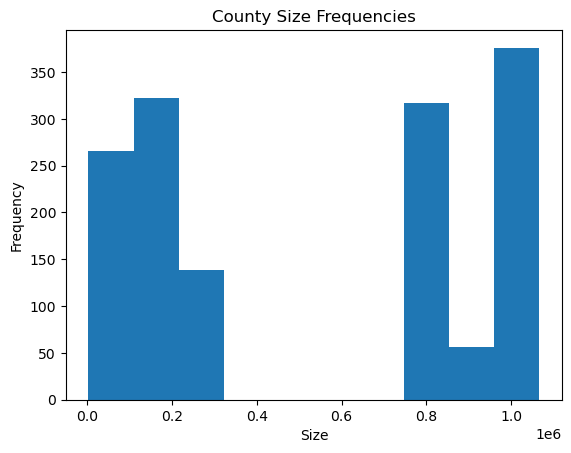

In [ ]:
#Displays the county size column as a default histogram.
import pandas as pd
dftemp = pd.read_csv("All Awards w CountySize.csv", usecols=['county_size'])
data = np.array(dftemp)
plt.hist(data)
plt.title('County Size Frequencies')
plt.xlabel('Size')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

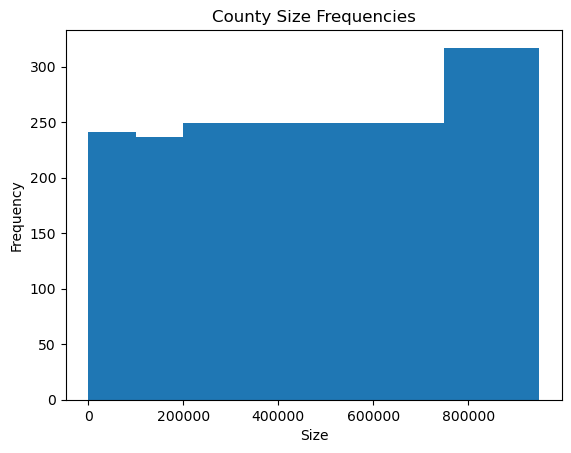

In [ ]:
import pandas as pd
dftemp = pd.read_csv("All Awards w CountySize.csv", usecols=['county_size'])
data = np.array(dftemp)
plt.hist(data, bins=[0,100000,200000,750000,950000])#Creates preset bins to force each county size into.
plt.title('County Size Frequencies')
plt.xlabel('Size')
plt.ylabel('Frequency')

The solution is to force the sets into 5 bins with unequal range, but similar frequencies. The large gap was solved by creating one large-ranged bin from population 200000 to population 750000. This bin is only slightly larger than the values of the previous two bins. The last bin has a larger frequency than the rest of the bins, however this bin is also dominated by only four counties, which will produce a meaningful result. For these reasons, the dataset is will be further transformed by placing each transaction in one of these five bins representing a ratio of county size.

Below is the data set after the new column for the county size ratio bins has been added.

In [6]:
#Displays the top transactions for the final compiled set of transactions.
import pandas as pd
apriori = pd.read_csv(r"C:\Users\Fnsp1\Downloads\PrimeAwardSummariesAndSubawards_2026-02-12_H23M45S15539241\All Awards Final.csv")
apriori.head()

,award_id_fain,disaster_emergency_fund_codes,obligated_amount_from_COVID-19_supplementals,obligated_amount_from_IIJA_supplemental,total_obligated_amount,awarding_agency_name,awarding_sub_agency_name,recipient_name,recipient_address_line_1,recipient_address_line_2,recipient_city_name,recipient_county_name,county_size,county_size_ratio,assistance_type_description,prime_award_base_transaction_description,business_types_description,usaspending_permalink
0,2505GA5MAP,Q: Not Designated Nonemergency/Emergency/Disas...,NaN,NaN,1.284996e+10,Department of Health and Human Services,Centers for Medicare and Medicaid Services,GEORGIA DEPARTMENT OF COMMUNITY HEALTH,2 PEACHTREE ST NW,NaN,ATLANTA,FULTON,1066710,>950000,BLOCK GRANT (A),MEDICAID ENTITLEMENT FOR 15 - FY 2026 - T19,STATE GOVERNMENT,https://www.usaspending.gov/award/ASST_NON_250...
1,2405GA5MAP,Q: Not Designated Nonemergency/Emergency/Disas...,NaN,NaN,9.894475e+09,Department of Health and Human Services,Centers for Medicare and Medicaid Services,GEORGIA DEPARTMENT OF COMMUNITY HEALTH,2 PEACHTREE ST NW,NaN,ATLANTA,FULTON,1066710,>950000,BLOCK GRANT (A),MEDICAID ENTITLEMENT FOR 15 - FY 2025 - T19,STATE GOVERNMENT,https://www.usaspending.gov/award/ASST_NON_240...
2,2110GACSC6,V: Non-emergency P.L. 117-2,967844677.0,NaN,9.678447e+08,Department of Health and Human Services,Administration for Children and Families,DEPARTMENT OF EARLY CARE & LEARNING GEORGIA,2 MLK JR DR SE 754 E TOWER,"SUITE 754, EAST TOWER",ATLANTA,FULTON,1066710,>950000,BLOCK GRANT (A),CSC6-2021,STATE GOVERNMENT,https://www.usaspending.gov/award/ASST_NON_211...
3,2110GACDC6,V: Non-emergency P.L. 117-2,605401332.0,NaN,6.054013e+08,Department of Health and Human Services,Administration for Children and Families,DEPARTMENT OF EARLY CARE & LEARNING GEORGIA,2 MLK JR DR SE 754 E TOWER,"SUITE 754, EAST TOWER",ATLANTA,FULTON,1066710,>950000,BLOCK GRANT (A),CDC6-2021,STATE GOVERNMENT,https://www.usaspending.gov/award/ASST_NON_211...
4,2405GA5021,Q: Not Designated Nonemergency/Emergency/Disas...,NaN,NaN,5.466382e+08,Department of Health and Human Services,Centers for Medicare and Medicaid Services,GEORGIA DEPARTMENT OF COMMUNITY HEALTH,2 PEACHTREE ST NW,NaN,ATLANTA,FULTON,1066710,>950000,BLOCK GRANT (A),MEDICAID ENTITLEMENT FOR 15 - FY 2025 - T21,STATE GOVERNMENT,https://www.usaspending.gov/award/ASST_NON_240...


After combining the datasets, recording the size ratios of the counties which these transactions take place, and justifying each outlier transaction amount, the final dataset is left at 1474 transactions, which will be transformed into a data matrix for the apriori algorithm to process.

The csv file is almost already in the format we want, where each row represents one transaction. To work with the data we care about, we will transform the table into one that reads only the parts of the csv file we want to see combinations in: awarding agency name, recipient name, county name, county size ratio, and assistance type.

In [ ]:
#Reads a csv file using only the characteristics of interest.
import pandas as pd
apriori = pd.read_csv("All Awards Final.csv", usecols=['award_id_fain','awarding_agency_name','recipient_name','recipient_county_name', 'county_size_ratio','assistance_type_description'])
apriori.head()

,award_id_fain,awarding_agency_name,recipient_name,recipient_county_name,county_size_ratio,assistance_type_description
0,2505GA5MAP,Department of Health and Human Services,GEORGIA DEPARTMENT OF COMMUNITY HEALTH,FULTON,>950000,BLOCK GRANT (A)
1,2405GA5MAP,Department of Health and Human Services,GEORGIA DEPARTMENT OF COMMUNITY HEALTH,FULTON,>950000,BLOCK GRANT (A)
2,FA862506C6456,Department of Defense,LOCKHEED MARTIN CORP,COBB,75000-950000,DEFINITIVE CONTRACT
3,FA862514C6450,Department of Defense,LOCKHEED MARTIN CORP,COBB,75000-950000,DEFINITIVE CONTRACT
4,SLFRP1029,Department of the Treasury,STATE OF GEORGIA,FULTON,>950000,"DIRECT PAYMENT FOR SPECIFIED USE, AS A SUBSIDY..."


# Data Mining

After generating a csv file using only the columns which association rules and frequent sets are to be generated from, the data was transferred into a 2D Matrix, where each item in a transaction was appended onto a list, and each list appended onto the list of transactions. Fortunately, the data is already in transactional format, so it only needed to be transferred into set format.

Next, we determined what we want our minimum support and minimum confidence to be. To decide support, we looked at the number of unique recipient names, as well as the number of unique agencies. Higher numbers of each will result in rarer instances of frequent sets with specific names.

In [ ]:
#Prints the number of unique recipients
df4 = pd.read_csv("All Awards Final.csv")

result = []

for r in df4['recipient_name']:
    key = r
    if key not in result:
        result.append(r)
print(len(result))

296


In [ ]:
#Prints the number of unique agencies
df4 = pd.read_csv("All Awards Final.csv")

result = []

for r in df4['awarding_agency_name']:
    key = r
    if key not in result:
        result.append(r)
print(len(result))

22


There appears to be 296 unique recipients, and only 22 unique agencies. This reveals that there may not be many recipients with a high number of transactions, however there are many recipients recieving the same kind of funds from the same agencies, which will be important context for determining if these agencies have different sized counties they tend to fund more. **Since the amount of recipients will naturally make frequent data sets rarer, and the specific recipients are relevant information for the sets, we used a minimum support value of 0.01.**

Before deciding a minimum confidence for generating rules, a csv file was generated with all of the frequent data sets for initial examining. Furthermore, a minimum length of 4 for each set was put in place to filter out any sets that did not contain a county or a county population size, as well as frequent sets that simply matched the county to the population range.

In [ ]:
import pandas as pd
import numpy as np
import statistics 
import matplotlib.pyplot as plt
import mlxtend
from mlxtend.frequent_patterns import apriori

#Initial code to load preprocessed data
ap = pd.read_csv(r"C:\Users\Fnsp1\Downloads\PrimeAwardSummariesAndSubawards_2026-02-12_H23M45S15539241\All Awards Final.csv", usecols=['awarding_agency_name','recipient_name','recipient_county_name', 'county_size_ratio','assistance_type_description'])
ap.head()

,awarding_agency_name,recipient_name,recipient_county_name,county_size_ratio,assistance_type_description
0,Department of Health and Human Services,GEORGIA DEPARTMENT OF COMMUNITY HEALTH,FULTON,>950000,BLOCK GRANT (A)
1,Department of Health and Human Services,GEORGIA DEPARTMENT OF COMMUNITY HEALTH,FULTON,>950000,BLOCK GRANT (A)
2,Department of Health and Human Services,DEPARTMENT OF EARLY CARE & LEARNING GEORGIA,FULTON,>950000,BLOCK GRANT (A)
3,Department of Health and Human Services,DEPARTMENT OF EARLY CARE & LEARNING GEORGIA,FULTON,>950000,BLOCK GRANT (A)
4,Department of Health and Human Services,GEORGIA DEPARTMENT OF COMMUNITY HEALTH,FULTON,>950000,BLOCK GRANT (A)


In [ ]:
#Transforms the data into a list of sets of variables, where each row represents one transaction
transactions = []
for i in range(0,len(ap)):
    transactions.append([str(ap.values[i,j]) for j in range (0,5)])

In [ ]:
#Encodes the data to work with mlxtend apriori
import mlxtend.preprocessing
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

In [ ]:
#Generates sets of frequent items and prints the total number of frequent sets with a min support of 0.01
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)
print("Total Frequent Itemsets:", frequent_itemsets.shape[0])

Total Frequent Itemsets: 534


In [ ]:
#Generates a new list of sets only containing sets with four or more items to further prune useless data
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
frequent_itemsets = frequent_itemsets[ (frequent_itemsets['length'] >= 4) &
                   (frequent_itemsets['support'] >= 0.01) ]
frequent_itemsets.to_csv('AprioriSets.csv')

In [ ]:
#Visualize the list of sets
sets = pd.read_csv(r"C:\Users\Fnsp1\Downloads\AprioriSets.csv")
display(sets)

,Unnamed: 0,support,itemsets,length
0,435,0.090971,frozenset({'DIRECT PAYMENT WITH UNRESTRICTED U...,4
1,436,0.010183,frozenset({'DIRECT PAYMENT WITH UNRESTRICTED U...,4
2,437,0.014257,"frozenset({'COLUMBIA', '100000-200000', 'DIREC...",4
3,438,0.011541,"frozenset({'Department of Defense', '100000-20...",4
4,439,0.010183,frozenset({'DIRECT PAYMENT WITH UNRESTRICTED U...,4
...,...,...,...,...
94,529,0.025119,"frozenset({'>950000', 'GEORGIA TECH APPLIED RE...",5
95,530,0.028513,"frozenset({'>950000', 'Social Security Adminis...",5
96,531,0.021045,"frozenset({'>950000', 'Social Security Adminis...",5
97,532,0.013578,"frozenset({'>950000', 'Department of Education...",5


## Frequent Sets

The data sets below display the frequent sets and rules displayed after apriori was implemented. Within the collection of frequent sets of data, these are the main patterns that are being discovered:

In [ ]:
df = pd.read_csv('AprioriSets.csv')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df.head()

,Unnamed: 0,support,itemsets,length
0,444,0.097760,"frozenset({'100000-200000', 'MULTIPLE RECIPIEN...",4
1,435,0.090971,"frozenset({'Social Security Administration', '...",4
2,458,0.083503,"frozenset({'200000-750000', 'MULTIPLE RECIPIEN...",4
3,492,0.049559,"frozenset({'MULTIPLE RECIPIENTS', 'Social Secu...",4
4,465,0.045485,"frozenset({'75000-950000', 'Department of Defe...",4


1. Direct payments from the Social Security Administration dominate the most common sets for every county ratio, excluding size 750,000 - 950,000. The administration appears commonly with size 0 - 100,000 with support value of 0.091, size 100,000 - 200,000 with support value of 0.098, size 200,000 - 750,000 with support value of 0.084, and size >950,000 with support value of 0.05. While these support values may appear small, they reveal large amounts of social security funding in all of these regions, ranging from 50 - 150 transactions each.

In [ ]:
df = pd.read_csv('AprioriSets2.csv')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df.head()

,Unnamed: 0,support,itemsets,length
0,465,0.045485,"frozenset({'75000-950000', 'Department of Defe...",4
1,462,0.039375,"frozenset({'75000-950000', 'DELIVERY ORDER', '...",4
2,471,0.021724,"frozenset({'DEKALB', 'Department of Health and...",4
3,467,0.016293,"frozenset({'DEKALB', 'Department of Health and...",4
4,468,0.010862,"frozenset({'DEKALB', 'EMORY UNIVERSITY', '7500...",4


2. Regions of size 750,000 - 950,000 appear the most in receiving delivery orders from the Department of Defense, with support of 0.039. This is due to the presence of Lockheed Martin Corp in Cobb County, which is a top recipient of contracts, and therefore skews the award type frequency in this area. The only other non-social security awards that frequently appear in this region are awards made to Emory University in DeKalb, with delivery order contracts appearing at a support value of 0.021 and cooperative agreements appearing at support value of 0.016.

In [ ]:
df = pd.read_csv('AprioriSetsF.csv')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df.head()

,Unnamed: 0,support,itemsets,length
0,488,0.034623,"frozenset({'FULTON', 'MULTIPLE RECIPIENTS', 'D...",4
1,481,0.023082,"frozenset({'BLOCK GRANT (A)', 'Department of H...",4
2,501,0.035302,"frozenset({'FORMULA GRANT (A)', 'Department of...",4
3,495,0.016293,"frozenset({'FORMULA GRANT (A)', 'FULTON', 'Dep...",4
4,493,0.011541,"frozenset({'FORMULA GRANT (A)', 'FULTON', 'Dep...",4


3. Only larger regions appear to receive different grant types from a larger variety of agencies. Of the sets with relevant support, Fulton is the only county to receive block grants (Department of Health and Human services with support value 0.023) or formula grants (Department of Education at support value of 0.016, Department of Transportation at support value 0.035, and Department of Agriculture at support value 0.011). 

In [ ]:
df = pd.read_csv('AprioriSetsV.csv')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df.head(4)

,Unnamed: 0,support,itemsets,length
0,451.0,0.028513,"frozenset({'200000-750000', 'Department of Vet...",4.0
1,440.0,0.021724,"frozenset({'100000-200000', 'MULTIPLE RECIPIEN...",4.0
2,477.0,0.012220,"frozenset({'Department of Veterans Affairs', '...",4.0
3,487.0,0.012220,"frozenset({'Department of Veterans Affairs', '...",4.0


4. The Department of Veterans Affairs appears commonly in all regions, however unlike social security, they appear more frequently in smaller regions (Size 100,000 - 200,000 at support value 0.022 and 200,000 - 750,000 at support value 0.029, specifically in regions closer to size 250,000).

## Association Rules

In [ ]:
#Reloads the entire list of frequent sets to work with the association rule
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)
print("Total Frequent Itemsets:", frequent_itemsets.shape[0])

Total Frequent Itemsets: 534


In [ ]:
#Finds association rules with a min confidence of 0.7
from mlxtend.frequent_patterns import association_rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)
rules = rules[rules['antecedents'].apply(lambda x: len(x) >= 1) & rules['consequents'].apply(lambda x: len(x) >= 1)]
print("Association Rules:", rules.shape[0])
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5)
rules.to_csv('AllAprioriRules.csv')


Association Rules: 1289


In [ ]:
#Visualizes rules
sets = pd.read_csv(r"C:\Users\Fnsp1\Downloads\AllAprioriRules.csv")
display(sets)

,Unnamed: 0,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,0,frozenset({'DOUGHERTY'}),frozenset({'0-100000'}),0.014936,0.163612,0.014936,1.000000,6.112033,1.0,0.012492,inf,0.849070,0.091286,1.000000,0.545643
1,1,frozenset({'GLYNN'}),frozenset({'0-100000'}),0.016972,0.163612,0.016972,1.000000,6.112033,1.0,0.014195,inf,0.850829,0.103734,1.000000,0.551867
2,2,frozenset({'BIBB'}),frozenset({'100000-200000'}),0.013578,0.160896,0.013578,1.000000,6.215190,1.0,0.011393,inf,0.850654,0.084388,1.000000,0.542194
3,3,frozenset({'CLARKE'}),frozenset({'100000-200000'}),0.013578,0.160896,0.013578,1.000000,6.215190,1.0,0.011393,inf,0.850654,0.084388,1.000000,0.542194
4,4,frozenset({'COLUMBIA'}),frozenset({'100000-200000'}),0.015614,0.160896,0.015614,1.000000,6.215190,1.0,0.013102,inf,0.852414,0.097046,1.000000,0.548523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1284,1284,"frozenset({'Department of Transportation', 'GE...","frozenset({'>950000', 'FULTON', 'FORMULA GRANT...",0.032587,0.085540,0.029871,0.916667,10.716270,1.0,0.027084,10.973523,0.937225,0.338462,0.908872,0.632937
1285,1285,"frozenset({'Department of Transportation', 'FO...",frozenset({'GEORGIA DEPARTMENT OF TRANSPORTATI...,0.036660,0.032587,0.029871,0.814815,25.004630,1.0,0.028676,5.224033,0.996540,0.758621,0.808577,0.865741
1286,1286,frozenset({'GEORGIA DEPARTMENT OF TRANSPORTATI...,"frozenset({'>950000', 'FULTON', 'Department of...",0.029871,0.039375,0.029871,1.000000,25.396552,1.0,0.028695,inf,0.990203,0.758621,1.000000,0.879310
1287,1287,frozenset({'Department of Transportation'}),frozenset({'GEORGIA DEPARTMENT OF TRANSPORTATI...,0.041412,0.029871,0.029871,0.721311,24.147541,1.0,0.028634,3.481051,1.000000,0.721311,0.712730,0.860656


To explore whether these trends were coincidence or not, the association rules were generated into a csv file. **A minimum confidence of 0.8 was implemented to filter out frequent data sets with weak association, as well as confirming the legitimacy of the trends found in the frequent data sets.**

**>950,000**

In [ ]:
df = pd.read_csv('RealAprioriRulesL95.csv')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df.head(10)

,Unnamed: 0,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,27,frozenset({'FORMULA GRANT (A)'}),frozenset({'>950000'}),0.095723,0.2926,0.086897,0.907801,3.102532,1,0.058889,7.672568,0.749419,0.288288,0.869666,0.602393
1,22,frozenset({'BLOCK GRANT (A)'}),frozenset({'>950000'}),0.023082,0.2926,0.023082,1.000000,3.417633,1,0.016328,inf,0.724114,0.078886,1.000000,0.539443
2,302,"frozenset({'PROJECT GRANT (B)', 'FULTON'})",frozenset({'>950000'}),0.033265,0.2926,0.033265,1.000000,3.417633,1,0.023532,inf,0.731742,0.113689,1.000000,0.556845
3,26,frozenset({'Department of Transportation'}),frozenset({'>950000'}),0.041412,0.2926,0.040733,0.983607,3.361607,1,0.028616,43.151392,0.732873,0.138889,0.976826,0.561409
4,25,frozenset({'Department of Agriculture'}),frozenset({'>950000'}),0.015614,0.2926,0.012899,0.826087,2.823262,1,0.008330,4.067549,0.656044,0.043678,0.754152,0.435085
5,262,frozenset({'Department of Health and Human Ser...,frozenset({'>950000'}),0.059742,0.2926,0.059742,1.000000,3.417633,1,0.042261,inf,0.752347,0.204176,1.000000,0.602088
6,258,"frozenset({'Department of Education', 'FORMULA...",frozenset({'>950000'}),0.016293,0.2926,0.016293,1.000000,3.417633,1,0.011526,inf,0.719117,0.055684,1.000000,0.527842
7,307,"frozenset({'Social Security Administration', '...",frozenset({'>950000'}),0.028513,0.2926,0.028513,1.000000,3.417633,1,0.020170,inf,0.728162,0.097448,1.000000,0.548724
8,309,"frozenset({'Social Security Administration', '...",frozenset({'>950000'}),0.021045,0.2926,0.021045,1.000000,3.417633,1,0.014888,inf,0.722607,0.071926,1.000000,0.535963
9,265,"frozenset({'Department of Homeland Security', ...",frozenset({'>950000'}),0.013578,0.2926,0.013578,1.000000,3.417633,1,0.009605,inf,0.717137,0.046404,1.000000,0.523202


These top rules for county sizes over 950,000 further supports the variety of businesses and programs that are found in larger regions over more rural areas. Here, we can see that Fulton county is the only county in the data that receives block grants and project grants, and is also a the major recipient of formula grants. The other rules, as well as the consistent lift values over 3, suggests this is not coincidence. Larger counties, such as those in the Atlanta area, house the majority of state government program headquarters, such as the Georgia Department of Education. 

**750,000 - 950,000**

In [ ]:
df = pd.read_csv('RealAprioriRules7-9.csv')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df.head(4)

,Unnamed: 0,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,207,"frozenset({'Department of Defense', 'LOCKHEED ...",frozenset({'750000-950000'}),0.045485,0.213849,0.045485,1.0,4.67619,1,0.035758,inf,0.823613,0.212698,1.0,0.606349
1,193,"frozenset({'DEKALB', 'EMORY UNIVERSITY'})",frozenset({'750000-950000'}),0.018330,0.213849,0.018330,1.0,4.67619,1,0.014410,inf,0.800830,0.085714,1.0,0.542857
2,180,"frozenset({'COBB', 'MULTIPLE RECIPIENTS'})",frozenset({'750000-950000'}),0.033944,0.213849,0.033944,1.0,4.67619,1,0.026685,inf,0.813774,0.158730,1.0,0.579365
3,196,"frozenset({'DEKALB', 'MULTIPLE RECIPIENTS'})",frozenset({'750000-950000'}),0.031229,0.213849,0.031229,1.0,4.67619,1,0.024551,inf,0.811493,0.146032,1.0,0.573016


These rules show a specific bias in counties of this size range. Lockheed Martin Corp. in Marietta and Emory University in DeKalb are both frequent recipients of government transactions. While this does not demonstrate patterns related to specific awarding agencies, it does display how larger establishments in larger areas are more likely to receive more funding transactions than businesses in smaller areas. The lift value of over 4 in all of these rules shows that this is not coincidence.

**200,000 - 750,000**

In [ ]:
df = pd.read_csv('RealAprioriRules2-7.csv')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df.head(7)

,Unnamed: 0,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,150,"frozenset({'HENRY', 'DIRECT PAYMENT WITH UNRES...",frozenset({'200000-750000'}),0.022403,0.169043,0.022403,1.0,5.915663,1,0.018616,inf,0.850000,0.132530,1.0,0.566265
1,134,frozenset({'DIRECT PAYMENT WITH UNRESTRICTED U...,frozenset({'200000-750000'}),0.014936,0.169043,0.014936,1.0,5.915663,1,0.012411,inf,0.843556,0.088353,1.0,0.544177
2,126,frozenset({'DIRECT PAYMENT WITH UNRESTRICTED U...,frozenset({'200000-750000'}),0.014257,0.169043,0.014257,1.0,5.915663,1,0.011847,inf,0.842975,0.084337,1.0,0.542169
3,155,frozenset({'DIRECT PAYMENT WITH UNRESTRICTED U...,frozenset({'200000-750000'}),0.014257,0.169043,0.014257,1.0,5.915663,1,0.011847,inf,0.842975,0.084337,1.0,0.542169
4,156,"frozenset({'RICHMOND', 'DIRECT PAYMENT WITH UN...",frozenset({'200000-750000'}),0.014257,0.169043,0.014257,1.0,5.915663,1,0.011847,inf,0.842975,0.084337,1.0,0.542169
5,147,frozenset({'DIRECT PAYMENT WITH UNRESTRICTED U...,frozenset({'200000-750000'}),0.012899,0.169043,0.012899,1.0,5.915663,1,0.010718,inf,0.841816,0.076305,1.0,0.538153
6,128,frozenset({'DIRECT PAYMENT WITH UNRESTRICTED U...,frozenset({'200000-750000'}),0.010862,0.169043,0.010862,1.0,5.915663,1,0.009026,inf,0.840082,0.064257,1.0,0.532129


All of these rules show direct payments to different counties of this size region. These rules support both the findings of social security being prominent across all counties, as well as the surprising finding that veterans compensation appears more prominently in smaller areas with a high confidence and lift value.

**100,000 - 200,000**

In [ ]:
df = pd.read_csv('RealAprioriRules1-2.csv')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df.head(7)

,Unnamed: 0,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,116,"frozenset({'Department of Defense', 'HOUSTON'})",frozenset({'100000-200000'}),0.015614,0.160896,0.015614,1.0,6.21519,1,0.013102,inf,0.852414,0.097046,1.0,0.548523
1,92,frozenset({'DIRECT PAYMENT WITH UNRESTRICTED U...,frozenset({'100000-200000'}),0.014257,0.160896,0.014257,1.0,6.21519,1,0.011963,inf,0.851240,0.088608,1.0,0.544304
2,90,frozenset({'DIRECT PAYMENT WITH UNRESTRICTED U...,frozenset({'100000-200000'}),0.010183,0.160896,0.010183,1.0,6.21519,1,0.008545,inf,0.847737,0.063291,1.0,0.531646
3,107,"frozenset({'HOUSTON', 'DIRECT PAYMENT WITH UNR...",frozenset({'100000-200000'}),0.014257,0.160896,0.014257,1.0,6.21519,1,0.011963,inf,0.851240,0.088608,1.0,0.544304
4,100,frozenset({'DIRECT PAYMENT WITH UNRESTRICTED U...,frozenset({'100000-200000'}),0.010183,0.160896,0.010183,1.0,6.21519,1,0.008545,inf,0.847737,0.063291,1.0,0.531646
5,104,frozenset({'DIRECT PAYMENT WITH UNRESTRICTED U...,frozenset({'100000-200000'}),0.010183,0.160896,0.010183,1.0,6.21519,1,0.008545,inf,0.847737,0.063291,1.0,0.531646
6,108,frozenset({'DIRECT PAYMENT WITH UNRESTRICTED U...,frozenset({'100000-200000'}),0.010183,0.160896,0.010183,1.0,6.21519,1,0.008545,inf,0.847737,0.063291,1.0,0.531646


The rules here follow the same principal as the ones in the size region directly above it. The higher lift value here shows a decreased variety in programs for smaller counties, as almost of the programs here are social security and veterans compensation. There is a high-confidence, high lift rule demonstrating a frequent amount of contracts from the Department of Defense given the size range of Houston. This is most likely due to the high number of establishments in Warner Robins that perform services at the aid of the U.S. Air Force.

# Interpretations

When examining all of the major findings from the frequent sets and rules, the majority of findings were trivial, and simply suggest common geographical patterns or common knowledge. 

The biggest pattern discovered was the large amount of social security transactions distributed in every region of Georgia. This suggests that there are a high amount of retired individuals and families within the state that receive social security or medicaid. The large amount of veterans affairs transactions in smaller counties might suggest a large amount of veterans who receive benefits from multiple government programs. However, without comparing these results to another state, such as Alabama, there is no way of knowing if these numbers are especially high compared to other areas in the country, and without the public ability to see every individual who collects these benefits, there is no way of determining how many of these transactions are legitimate and how many are fraudulent. This discovery does not reveal any differences amongst Georgia regions in regards to funding patterns.

The large variety of transactions in large regions, such as Fulton County and DeKalb county, is a relevant pattern, however it simply reaffirms that larger businesses and government organizations are found in more urban areas with lots of infrastructure and high population. It is no surprise that they would skew the support values for sets regarding awarding agencies and county sizes. Another factor that appears to skew the support for frequent sets is the existence of military-based operations, such as Lockheed and those found in Warner Robins. Both exist in different sized regions, however they receive a lot of Georgia's federal funding through various contracts. This does not help determine the difference between different sized regions, rather it reaffirms the existence of important industries, such as military-based businesses, in larger regions.

The most surprising discovery was the high number of transactions from the Department of Veterans Affairs in rural and suburban regions. The biggest significance of this is suggesting the geographic existence of veterans in smaller areas, along with the various support programs that exist in them. This could be helpful for any person or organization looking to establish further support for veterans of all kinds. The number of people collecting government support does suggest the existing need in these areas for their support, and looking in these smaller areas that house many veterans may be a good place to start.

# Limitations

While the rules generated by the apriori algorithm are relevant with strong support, the sheer volume of transactions and different recipients makes it difficult to find patterns that are not obvious. The descriptions of each transaction vary heavily, making it nearly impossible to use them as a factor in finding frequent sets of transaction characteristics among different regions. Furthermore, without examining other states in the same manner, it is difficult to display the weight of the significant rules found here. In the future, this same algorithm should be performed in other states of similar size in order to compare their sets. This would better reveal of the high number of social security transactions is exclusive to Georgia, or if they are the largest distribution of federal funds in the country. 

Another limitation that may have effected the results is the categories used to create the sets. The county names were kept in addition to their sizes in order to help explain common sets further. However, with the imbalance in counties per size ratio, some sets appear as a consequence of county characteristics being paired with their names. Furthermore, certain recipients only receive specific types of funds from specific agencies. While the less frequent recipients were naturally filtered out, this lead to frequent sets appearing with identical information, but different support values. This was mitigated by favoring certain category combinations over others, such as awarding agencies paired with county sizes, however it is possible that this could have skewed the results and led to the large amount of trivial patterns.

# Plans for M3

The original plan was to employ anomaly detection using an isolation forest to explain the causes of abnormally large transaction values. However, when exploring outliers in this milestone, it revealed that the largest transactions did not have abnormal characteristics when compared to other transactions. Furthermore, I want to shift into a different approach that may reveal more surprising information than the frequency sets generated by the apriori method. I am shifting my focus onto comparing the characteristics of the recipients themselves as opposed to the geographic regions they appear in. To do this, I will be using K-Means to cluster recipients based on the total amount of funds they received in 2025, the amount of funds dedicated to disaster relief, the amount of awards they received, and the amount of agencies that fund them. Performing this method will help answer the question, **"What natural groupings cam be found among federal funding recipients based on the characteristics of their transactions?"**

# M3: Updated Analysis

Coming out of the previous analysis from M2, the goal for M3 is to perform a deeper exploration on the current dataset to find more surprising patterns than those discovered previously. When exploring the common co-occurences in M2, the patterns proved to show trivial geographic information and unsurprising high frequencies of individual support such as social security.  We will begin M3 by performing apriori data mining three more times, each with different parameters, then comparing the patterns found in each list of frequent sets. By changing the parameters we are aiming to find patterns in different contexts, seeing if there are any surprising changes to the established findings of M2 or if the previous finding are merely reinforced. The parameters that will be explored will be as followed:

1. Finding patterns in co-occuring agencies, business types, and counties.
2. Finding patterns within co-occuring words in each transaction's description.
3. Using apriori to find surprising relations between specific agencies and recipients.

With these new methods of pattern discovery, we will be extending on the previous research question: "What combinations of awarding agencies, recipients, and funding types frequently co-occur in different regions of Georgia?" Despite different parameters, each parameter serves to be an extension of the parameters mentioned in the discovery question, while allowing the ability to compare the results of each apriori run by how surprising the data is. 

In addition to new apriori parameters, we will also be answering the last discovery question: "What natural groupings can be found among federal funding recipients based on the characteristics of their transactions?" To do this, we will use k-means clustering to group recipients by their total obligations and the amount of awards they receive. The goal is to discover any like characteristics between the individuals that end up clustered in each group. Once this data mining method is fully implemented, the results will also be compared to the previous apriori results in how surprising or trivial they are. Focusing exclusively on characteristic (recipients), grouping them, and looking at the similar characteristics of their businesses and their transactions should reveal more information than examining multiple parameters and which ones appear more frequently together, which is why clustering was chosen as an addition to apriori for further exploration.

# Deeper Exploration of Apriori: Three new parameter sets

### Finding patterns in co-occuring agencies, business types, and counties.

In the first of the second wave of apriori runs, we will be finding patterns in co-occuring agencies, business types, and counties. Specifically, we are exploring relations between agencies and business types to determine any common relations or exclusivity, and counties and business types to determine of there are any surprising commonalities between what business types are found where. We hope that by reducing the number of parameters and by broadening the recipients to their business types that we will find more surprising results at a broader level.

Just like before, a table was created out of the previously preprocessed data where each row represents one transaction made up of the three parameters mentioned. This table was then fed through the apriori code used before. for this run, we kept the same minimum support value of 0.01 to properly adjust for the natural variety in transaction parameters, and we kept the same minimum confidence value of 0.7 to filter out weak patterns and confirm the legitimacy of the existing patterns.

In [ ]:
import mlxtend
from mlxtend.frequent_patterns import apriori

#Loads the preprocessed data using only the specified parameters
ap = pd.read_csv(r"C:\Users\Fnsp1\Downloads\PrimeAwardSummariesAndSubawards_2026-02-12_H23M45S15539241\All Awards Final.csv", usecols=['awarding_agency_name','recipient_county_name','business_types_description'])
ap.head()

,awarding_agency_name,recipient_county_name,business_types_description
0,Department of Health and Human Services,FULTON,STATE GOVERNMENT
1,Department of Health and Human Services,FULTON,STATE GOVERNMENT
2,Department of Health and Human Services,FULTON,STATE GOVERNMENT
3,Department of Health and Human Services,FULTON,STATE GOVERNMENT
4,Department of Health and Human Services,FULTON,STATE GOVERNMENT


In [ ]:
#Creates a list of sets, each one containing a set of variables for one transaction
transactions = []
for i in range(0,len(ap)):
    transactions.append([str(ap.values[i,j]) for j in range (0,3)])

In [ ]:
#Encodes the data for mxltend
import mlxtend.preprocessing
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

In [ ]:
#Generates a list of frequent sets of data with min support of 0.01
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)
print("Total Frequent Itemsets:", frequent_itemsets.shape[0])
frequent_itemsets.to_csv('agencyBusinessRelations.csv')

Total Frequent Itemsets: 122


In [12]:
sets = pd.read_csv(r"C:\Users\Fnsp1\Downloads\agencyBusinessRelations.csv")
display(sets)

,Unnamed: 0,support,itemsets
0,0,0.013578,frozenset({'BIBB'})
1,1,0.033265,frozenset({'CHATHAM'})
2,2,0.012220,frozenset({'CHEROKEE'})
3,3,0.013578,frozenset({'CLARKE'})
4,4,0.015614,frozenset({'CLAYTON'})
5,5,0.090971,frozenset({'COBB'})
6,6,0.015614,frozenset({'COLUMBIA'})
7,7,0.179226,frozenset({'CORPORATE NOT TAX EXEMPT'})
8,8,0.044128,frozenset({'CORPORATE TAX EXEMPT'})
9,9,0.010183,frozenset({'COWETA'})


In [ ]:
#Calculates and generates association rules using min confidence of 0.7
from mlxtend.frequent_patterns import association_rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)
rules = rules[rules['antecedents'].apply(lambda x: len(x) >= 1) & rules['consequents'].apply(lambda x: len(x) >= 1)]
print("Association Rules:", rules.shape[0])
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5)
rules.to_csv('RelationsRules1.csv')

Association Rules: 62


In [14]:
sets = pd.read_csv(r"C:\Users\Fnsp1\Downloads\RelationsRules1.csv")
display(sets)

,Unnamed: 0,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,0,frozenset({'BIBB'}),frozenset({'INDIVIDUAL'}),0.013578,0.445350,0.010183,0.750000,1.684070,1.0,0.004136,2.218601,0.411792,0.022693,0.549266,0.386433
1,1,frozenset({'CHEROKEE'}),frozenset({'INDIVIDUAL'}),0.012220,0.445350,0.010862,0.888889,1.995935,1.0,0.005420,4.991853,0.505155,0.024316,0.799674,0.456640
2,2,frozenset({'CLAYTON'}),frozenset({'INDIVIDUAL'}),0.015614,0.445350,0.014936,0.956522,2.147800,1.0,0.007982,12.756959,0.542884,0.033486,0.921611,0.495029
3,3,frozenset({'CLAYTON'}),frozenset({'Social Security Administration'}),0.015614,0.365920,0.012899,0.826087,2.257562,1.0,0.007185,3.645961,0.565880,0.034991,0.725724,0.430669
4,4,frozenset({'COLUMBIA'}),frozenset({'INDIVIDUAL'}),0.015614,0.445350,0.014257,0.913043,2.050172,1.0,0.007303,6.378479,0.520361,0.031915,0.843223,0.472528
5,5,frozenset({'General Services Administration'}),frozenset({'CORPORATE NOT TAX EXEMPT'}),0.014257,0.179226,0.010862,0.761905,4.251082,1.0,0.008307,3.447251,0.775826,0.059480,0.709914,0.411255
6,6,frozenset({'CORPORATE TAX EXEMPT'}),frozenset({'Department of Defense'}),0.044128,0.180584,0.033944,0.769231,4.259688,1.0,0.025976,3.550803,0.800568,0.177936,0.718374,0.478600
7,7,frozenset({'DOUGLAS'}),frozenset({'INDIVIDUAL'}),0.010183,0.445350,0.010183,1.000000,2.245427,1.0,0.005648,inf,0.560357,0.022866,1.000000,0.511433
8,8,frozenset({'Department of Agriculture'}),frozenset({'FULTON'}),0.015614,0.254582,0.012220,0.782609,3.074087,1.0,0.008245,3.428921,0.685402,0.047368,0.708363,0.415304
9,9,frozenset({'Department of Agriculture'}),frozenset({'STATE GOVERNMENT'}),0.015614,0.137135,0.012220,0.782609,5.706845,1.0,0.010079,3.969179,0.837854,0.086957,0.748059,0.435859


Compared to the results of the previous set of data, the rules generated here similarly generate more trivial data based on geographic data. Larger counties, such as Fulton, appear in a bigger variety of rules than smaller counties due to the higher concentration of businesses found within them, while smaller counties appear in less rules and exclusively appear at high support values given that the funding agency is the Social Security Administration. Furthermore, there is triviality in the business types in which each business funds. Both the Department of Defense and Corporate companies exclusively co-occur at support values ranging from 0.03 with a confidence of 0.76. The only reason the confidence value is not 1 here is because of the existence of Lockheed Martin in Cobb County, making both Fulton and Cobb a target for defense funding. Furthermore, less frequent departments, such as the Department of Transportation and the Department of Agriculture, all exclusively support State Governments found in Fulton County. This is more trivial information, since this funding is going directly to the state level departments of the same name, which acts as a middle man to the industries getting funded. Since we are exploring the state of Georgia's funding from a federal level, the data will not provide insight on who the state level departments are funding, however this would be irrelevant to the research questions. The trivial exclusivity of funds can be further examined by noticing that the Department of Education only co-occurs with State Controlled Institutions of Higher Education with support of 0.01 and confidence of 0.77. This only highlights the specialization of each federal department in the distribution of their funds.

Despite the trivial results between the first set of parameters and this set, there are two surprising results found. First, the Department of Veterans Affairs appears with INDIVIDUAL at a high support of 0.07, and a high confidence of 0.95, further reinforcing the high appearance of this department in various low population counties. This can possibly reveal two things: the high concentration of veterans in smaller counties or the low support of veterans in higher counties. This is unlikely to be ill-gotten funding either due to the previous discovered variety of veterans assistance in various counties. Therefore, this could be an indication of the rising need for veterans support across the state. Second, the Department of Health and Human services frequently co-occurs in multiple business types, those being NONPROFIT WITH 501C3 IRS STATUS (support of 0.03 and confidence of 0.8), Corporate Non-Tax Exempt (support of 0.02 and confidence of 0.74), and Private Education Institutions (support of 0.01 and confidence of 1). Since there is a Georgia Department of Public Health and a Georgia Department of Human Service, it is surprising to not see frequent co-occurences between them and the federal department. Furthermore, it is surprising to see frequent co-occurences with DeKalb, and not Fulton County. When re-examining the previous results, DeKalb is home to many large recipients of federal funding, such as Emory University, which most likely contributes to this discovery. Even so, it is surprising to see these companies receive more funding than the state government. This relation will be further examined in the next sets of apriori rules.

### Finding patterns within co-occuring words in each transaction's description.

Next, we will examine the descriptions of each transaction and see if there are any patterns in the words that frequently co-occur. With this parameter, we are attempting to reveal any specific re-occuring interests that are described in each transaction that would not be revealed in the broader parameter types we examined before. 

In the data frame we made for this run, we turned every description into a set of words by breaking apart the sentence into a word set. Each set of words is inserted into the frame, each row representing one transaction per description. We raised the support value to 0.06 due to the natural variety of words to filter out trivial words as much as we can. We kept the confidence level of 0.7 to only keep the strongest supported sets of words. 

In [ ]:
#Loads the preprocessed data using only the specified parameters
ap = pd.read_csv(r"C:\Users\Fnsp1\Downloads\PrimeAwardSummariesAndSubawards_2026-02-12_H23M45S15539241\All Awards Final.csv", usecols=['prime_award_base_transaction_description'])
ap.head()

,prime_award_base_transaction_description
0,MEDICAID ENTITLEMENT FOR 15 - FY 2026 - T19
1,MEDICAID ENTITLEMENT FOR 15 - FY 2025 - T19
2,CSC6-2021
3,CDC6-2021
4,MEDICAID ENTITLEMENT FOR 15 - FY 2025 - T21


In [ ]:
#Breaks down each description into a set of words and adds them to a list of transactions
allWordList = []
for item in ap['prime_award_base_transaction_description']:
    wordList = str(item).split()
    allWordList.append(wordList)

wordsDF = pd.DataFrame({'Description': allWordList})
wordsDF.head()

,Description
0,"[MEDICAID, ENTITLEMENT, FOR, 15, -, FY, 2026, ..."
1,"[MEDICAID, ENTITLEMENT, FOR, 15, -, FY, 2025, ..."
2,[CSC6-2021]
3,[CDC6-2021]
4,"[MEDICAID, ENTITLEMENT, FOR, 15, -, FY, 2025, ..."


In [ ]:
#Encoding for mxltend apriori
te = TransactionEncoder()
te_array = te.fit(allWordList).transform(allWordList)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

In [ ]:
#Generates list of frequent words with min support of 0.06
frequent_itemsets = apriori(df_encoded, min_support=0.06, use_colnames=True)
print("Total Frequent Itemsets:", frequent_itemsets.shape[0])
frequent_itemsets.to_csv('frequentWords.csv')

Total Frequent Itemsets: 64


In [19]:
sets = pd.read_csv(r"C:\Users\Fnsp1\Downloads\frequentWords.csv")
display(sets)

,Unnamed: 0,support,itemsets
0,0,0.365241,frozenset({'(RI)'})
1,1,0.365920,frozenset({'AGGREGATE'})
2,2,0.183299,frozenset({'AND'})
3,3,0.370672,frozenset({'BENEFITS'})
4,4,0.133741,frozenset({'FOR'})
5,5,0.066531,frozenset({'GRANT'})
6,6,0.069246,frozenset({'IN'})
7,7,0.382892,frozenset({'INSURANCE'})
8,8,0.114732,frozenset({'OF'})
9,9,0.079430,frozenset({'PROGRAM'})


In [ ]:
#Generates association rules using min confidence of 0.7
from mlxtend.frequent_patterns import association_rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)
rules = rules[rules['antecedents'].apply(lambda x: len(x) >= 1) & rules['consequents'].apply(lambda x: len(x) >= 1)]
print("Association Rules:", rules.shape[0])
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5)
rules.to_csv('AprioriRulesWords.csv')

Association Rules: 240


,antecedents,consequents,support,confidence,lift
0,frozenset({(RI)}),frozenset({AGGREGATE}),0.365241,1.000000,2.732839
1,frozenset({AGGREGATE}),frozenset({(RI)}),0.365241,0.998145,2.732839
2,frozenset({(RI)}),frozenset({BENEFITS}),0.365241,1.000000,2.697802
3,frozenset({BENEFITS}),frozenset({(RI)}),0.365241,0.985348,2.697802
4,frozenset({(RI)}),frozenset({INSURANCE}),0.365241,1.000000,2.611702


In [21]:
sets = pd.read_csv(r"C:\Users\Fnsp1\Downloads\AprioriRulesWords.csv")
display(sets)

,Unnamed: 0,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,0,frozenset({'AGGREGATE'}),frozenset({'(RI)'}),0.365920,0.365241,0.365241,0.998145,2.732839,1.0,0.231592,342.135098,1.000000,0.998145,0.997077,0.999072
1,1,frozenset({'(RI)'}),frozenset({'AGGREGATE'}),0.365241,0.365920,0.365241,1.000000,2.732839,1.0,0.231592,inf,0.998930,0.998145,1.000000,0.999072
2,2,frozenset({'BENEFITS'}),frozenset({'(RI)'}),0.370672,0.365241,0.365241,0.985348,2.697802,1.0,0.229856,43.322301,1.000000,0.985348,0.976917,0.992674
3,3,frozenset({'(RI)'}),frozenset({'BENEFITS'}),0.365241,0.370672,0.365241,1.000000,2.697802,1.0,0.229856,inf,0.991444,0.985348,1.000000,0.992674
4,4,frozenset({'(RI)'}),frozenset({'INSURANCE'}),0.365241,0.382892,0.365241,1.000000,2.611702,1.0,0.225393,inf,0.972193,0.953901,1.000000,0.976950
5,5,frozenset({'INSURANCE'}),frozenset({'(RI)'}),0.382892,0.365241,0.365241,0.953901,2.611702,1.0,0.225393,13.769387,1.000000,0.953901,0.927375,0.976950
6,6,frozenset({'(RI)'}),frozenset({'RETIREMENT'}),0.365241,0.365241,0.365241,1.000000,2.737918,1.0,0.231840,inf,1.000000,1.000000,1.000000,1.000000
7,7,frozenset({'RETIREMENT'}),frozenset({'(RI)'}),0.365241,0.365241,0.365241,1.000000,2.737918,1.0,0.231840,inf,1.000000,1.000000,1.000000,1.000000
8,8,frozenset({'AGGREGATE'}),frozenset({'BENEFITS'}),0.365920,0.370672,0.365920,1.000000,2.697802,1.0,0.230284,inf,0.992505,0.987179,1.000000,0.993590
9,9,frozenset({'BENEFITS'}),frozenset({'AGGREGATE'}),0.370672,0.365920,0.365920,0.987179,2.697802,1.0,0.230284,49.458248,1.000000,0.987179,0.979781,0.993590


Unfortunately, this parameter only regurgitated the same trivial findings as before. There is only one set of meaningful words that frequently occur, those being "Benefits", "Aggregate", "(RI)", "Retirement", and "Insurance", which all co-occur with each other at support value of 0.37. These are all words that are used to describe transactions from the Social Security Administration, which reinforces their established rank of highest funding agency. This could also reveal the lack of any common interests among the awarding agencies and a nature of specific goals for each transaction, however this finding only shows a lack of patterns that we are looking for. 

### Using apriori to find surprising relations between specific agencies and recipients.

For the final run of apriori, the parameters will be the funding agency and the recipient. By using only these two parameters, the goal is to find patterns in the relationship between the agency and recipient. We are looking for agencies who fund multiple recipients, recipients who have exclusive relationships with one agency, and recipients who receive multiple transactions from the same agency. Because we are examining relational patterns, the context behind each frequent set will be different, however producing the results as frequent sets allows us to easily examine and interpret the relations. Because of this, we want to try to prune as little frequent sets as possible. Therefore, a very low minimum support value of 0.0006 and minimum confidence of 0.1 will be used to make sure sets that appear once appear in the results as well.

In [ ]:
#Loads the preprocessed data using only the specified parameters
ap = pd.read_csv(r"C:\Users\Fnsp1\Downloads\PrimeAwardSummariesAndSubawards_2026-02-12_H23M45S15539241\All Awards Final.csv", usecols=['awarding_agency_name','recipient_name'])
ap.head()

,awarding_agency_name,recipient_name
0,Department of Health and Human Services,GEORGIA DEPARTMENT OF COMMUNITY HEALTH
1,Department of Health and Human Services,GEORGIA DEPARTMENT OF COMMUNITY HEALTH
2,Department of Health and Human Services,DEPARTMENT OF EARLY CARE & LEARNING GEORGIA
3,Department of Health and Human Services,DEPARTMENT OF EARLY CARE & LEARNING GEORGIA
4,Department of Health and Human Services,GEORGIA DEPARTMENT OF COMMUNITY HEALTH


In [ ]:
#Creates a list of agency-recipient relationships
transactions = []
for i in range(0,len(ap)):
    transactions.append([str(ap.values[i,j]) for j in range (0,2)])

In [ ]:
#Encoding for mxltend apriori
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

In [ ]:
#Generates a list of frequent sets with min support of 0.0006
frequent_itemsets = apriori(df_encoded, min_support=0.0006, use_colnames=True)
print("Total Frequent Itemsets:", frequent_itemsets.shape[0])
frequent_itemsets.to_csv('A-RRelations3.csv')

Total Frequent Itemsets: 645


In [26]:
sets = pd.read_csv(r"C:\Users\Fnsp1\Downloads\A-RRelations3.csv")
display(sets)

,Unnamed: 0,support,itemsets
0,0,0.002716,"frozenset({'4K GLOBAL-ACC JV, LLC'})"
1,1,0.000679,frozenset({'ABACUS SOLUTIONS GROUP LLC'})
2,2,0.004073,frozenset({'ACC CONSTRUCTION CO INC'})
3,3,0.000679,frozenset({'ACCENTURE FEDERAL SERVICES LLC'})
4,4,0.000679,"frozenset({'ACTION PACT, INC.'})"
5,5,0.000679,frozenset({'ADAMS AND ASSOCIATES INC'})
6,6,0.000679,frozenset({'ADVON CORPORATION'})
7,7,0.000679,"frozenset({'AECOM TECHNICAL SERVICES, INC.'})"
8,8,0.000679,"frozenset({'AGILE DECISION SCIENCES, LLC'})"
9,9,0.000679,"frozenset({'AIRBOSS DEFENSE GROUP, LLC'})"


In [ ]:
#Creates list of association rules with a min confidence of 0.1
from mlxtend.frequent_patterns import association_rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)
rules = rules[rules['antecedents'].apply(lambda x: len(x) >= 1) & rules['consequents'].apply(lambda x: len(x) >= 1)]
print("Association Rules:", rules.shape[0])
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5)
rules.to_csv('ARRules4.csv')

Association Rules: 369


,antecedents,consequents,support,confidence,lift
0,"frozenset({4K GLOBAL-ACC JV, LLC})",frozenset({Department of Defense}),0.002716,1.0,5.537594
1,frozenset({ABACUS SOLUTIONS GROUP LLC}),frozenset({Department of Homeland Security}),0.000679,1.0,43.323529
2,frozenset({ACC CONSTRUCTION CO INC}),frozenset({Department of Defense}),0.004073,1.0,5.537594
3,frozenset({ACCENTURE FEDERAL SERVICES LLC}),frozenset({General Services Administration}),0.000679,1.0,70.142857
4,"frozenset({ACTION PACT, INC.})",frozenset({Department of Health and Human Serv...,0.000679,1.0,5.939516


In [28]:
sets = pd.read_csv(r"C:\Users\Fnsp1\Downloads\ARRules4.csv")
display(sets)

,Unnamed: 0,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,0,"frozenset({'4K GLOBAL-ACC JV, LLC'})",frozenset({'Department of Defense'}),0.002716,0.180584,0.002716,1.000000,5.537594,1.0,0.002225,inf,0.821647,0.015038,1.000000,0.507519
1,1,frozenset({'ABACUS SOLUTIONS GROUP LLC'}),frozenset({'Department of Homeland Security'}),0.000679,0.023082,0.000679,1.000000,43.323529,1.0,0.000663,inf,0.977582,0.029412,1.000000,0.514706
2,2,frozenset({'ACC CONSTRUCTION CO INC'}),frozenset({'Department of Defense'}),0.004073,0.180584,0.004073,1.000000,5.537594,1.0,0.003338,inf,0.822768,0.022556,1.000000,0.511278
3,3,frozenset({'ACCENTURE FEDERAL SERVICES LLC'}),frozenset({'General Services Administration'}),0.000679,0.014257,0.000679,1.000000,70.142857,1.0,0.000669,inf,0.986413,0.047619,1.000000,0.523810
4,4,"frozenset({'ACTION PACT, INC.'})",frozenset({'Department of Health and Human Ser...,0.000679,0.168364,0.000679,1.000000,5.939516,1.0,0.000565,inf,0.832201,0.004032,1.000000,0.502016
5,5,frozenset({'ADAMS AND ASSOCIATES INC'}),frozenset({'Department of Labor'}),0.000679,0.010183,0.000679,1.000000,98.200000,1.0,0.000672,inf,0.990489,0.066667,1.000000,0.533333
6,6,frozenset({'ADVON CORPORATION'}),frozenset({'Department of Defense'}),0.000679,0.180584,0.000679,1.000000,5.537594,1.0,0.000556,inf,0.819973,0.003759,1.000000,0.501880
7,7,"frozenset({'AECOM TECHNICAL SERVICES, INC.'})",frozenset({'Department of Defense'}),0.000679,0.180584,0.000679,1.000000,5.537594,1.0,0.000556,inf,0.819973,0.003759,1.000000,0.501880
8,8,"frozenset({'AGILE DECISION SCIENCES, LLC'})",frozenset({'Department of Defense'}),0.000679,0.180584,0.000679,1.000000,5.537594,1.0,0.000556,inf,0.819973,0.003759,1.000000,0.501880
9,9,"frozenset({'AIRBOSS DEFENSE GROUP, LLC'})",frozenset({'Department of Health and Human Ser...,0.000679,0.168364,0.000679,1.000000,5.939516,1.0,0.000565,inf,0.832201,0.004032,1.000000,0.502016


Unlike the results of the other apriori runs, we can start to see more surprising results. There appears to be a sizable difference between recipients funded by one agency vs multiple agencies, with there being more recipients with exclusive relations with a specific agency. This is not surprising on its own, however it also appears that the recipients who receive more than one transaction are the ones with exclusive relations. There are a hand full of recipients who have received transactions from multiple agencies, all of which are once of three kinds of businesses: a Georgia Agency, large university, or miscellaneous business who has received one transaction at some point from one of the leading agencies in transactions, those being the Department of Defense, Department of Health and Human Services, and Department of Education. Recipients who have transactions with multiple agencies due to one transaction don't have a high amount of collective transactions and become pruned when raising the minimum support value. The best way to interpret this is that the recipients with lower transaction counts are those who request funding from a specific agency for a specific purpose or project, while those who receive multiple transactions are mostly businesses who might operate off of the funds of one specific agency who funds them. While this may not be surprising, it is interesting to see the way the results shape this rule, and it provides more interesting and surprising rules than the runs that use multiple parameters. 

# Clustering Recipients by Total Obligations and Total Awards Received

Next, k-means clustering will be implemented to group recipients by their total obligations and total amount of awards received. In addition to answering the discovery questions, clustering will be directly compared to the previously implemented association rules by the surprising nature of their results. Apriori has already been compared to itself under different parameters several times, and now it will be compared to a data mining method which will start at a narrow scope, examining one parameter rather than examining the combination of multiple parameters together. Furthermore, k-means will allow us to examine quantitative data, such as money flow and transaction frequency, in a way which frequently appearing quantitative data cannot. 

### Data Mining 

Same as before, we will begin by loading the preprocessed csv file into a data frame, which can be transformed into a list of recipients and their attributes.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
#Loading the preprocessed data
data = pd.read_csv(r"C:\Users\Fnsp1\Downloads\PrimeAwardSummariesAndSubawards_2026-02-12_H23M45S15539241\All Awards Final.csv")
data.head()

,award_id_fain,disaster_emergency_fund_codes,obligated_amount_from_COVID-19_supplementals,obligated_amount_from_IIJA_supplemental,total_obligated_amount,awarding_agency_name,awarding_sub_agency_name,recipient_name,recipient_address_line_1,recipient_address_line_2,recipient_city_name,recipient_county_name,county_size,county_size_ratio,assistance_type_description,prime_award_base_transaction_description,business_types_description,usaspending_permalink
0,2505GA5MAP,Q: Not Designated Nonemergency/Emergency/Disas...,NaN,NaN,1.284996e+10,Department of Health and Human Services,Centers for Medicare and Medicaid Services,GEORGIA DEPARTMENT OF COMMUNITY HEALTH,2 PEACHTREE ST NW,NaN,ATLANTA,FULTON,1066710,>950000,BLOCK GRANT (A),MEDICAID ENTITLEMENT FOR 15 - FY 2026 - T19,STATE GOVERNMENT,https://www.usaspending.gov/award/ASST_NON_250...
1,2405GA5MAP,Q: Not Designated Nonemergency/Emergency/Disas...,NaN,NaN,9.894475e+09,Department of Health and Human Services,Centers for Medicare and Medicaid Services,GEORGIA DEPARTMENT OF COMMUNITY HEALTH,2 PEACHTREE ST NW,NaN,ATLANTA,FULTON,1066710,>950000,BLOCK GRANT (A),MEDICAID ENTITLEMENT FOR 15 - FY 2025 - T19,STATE GOVERNMENT,https://www.usaspending.gov/award/ASST_NON_240...
2,2110GACSC6,V: Non-emergency P.L. 117-2,967844677.0,NaN,9.678447e+08,Department of Health and Human Services,Administration for Children and Families,DEPARTMENT OF EARLY CARE & LEARNING GEORGIA,2 MLK JR DR SE 754 E TOWER,"SUITE 754, EAST TOWER",ATLANTA,FULTON,1066710,>950000,BLOCK GRANT (A),CSC6-2021,STATE GOVERNMENT,https://www.usaspending.gov/award/ASST_NON_211...
3,2110GACDC6,V: Non-emergency P.L. 117-2,605401332.0,NaN,6.054013e+08,Department of Health and Human Services,Administration for Children and Families,DEPARTMENT OF EARLY CARE & LEARNING GEORGIA,2 MLK JR DR SE 754 E TOWER,"SUITE 754, EAST TOWER",ATLANTA,FULTON,1066710,>950000,BLOCK GRANT (A),CDC6-2021,STATE GOVERNMENT,https://www.usaspending.gov/award/ASST_NON_211...
4,2405GA5021,Q: Not Designated Nonemergency/Emergency/Disas...,NaN,NaN,5.466382e+08,Department of Health and Human Services,Centers for Medicare and Medicaid Services,GEORGIA DEPARTMENT OF COMMUNITY HEALTH,2 PEACHTREE ST NW,NaN,ATLANTA,FULTON,1066710,>950000,BLOCK GRANT (A),MEDICAID ENTITLEMENT FOR 15 - FY 2025 - T21,STATE GOVERNMENT,https://www.usaspending.gov/award/ASST_NON_240...


To transform the data frame, we will create a table of recipients. Each row will have three columns, one for the name, and two for total obligations and award amount, which will represent the coordinates for each recipient. 

In [ ]:
#Creates three lists to hold each variable
Recipients = []
Obligations = []
awardAmount = []

count = 0
obl = 0
index = 0
#For every loop run, a unique recipient is found, then the total number of awards and total obligations are counted and added to their respective lists in the same index.
for item in data['recipient_name']:
    count = 0
    obl = 0
    index = 0
    if item not in Recipients:
        Recipients.append(str(item))
        for name in data['recipient_name']:
            if name == item:
                obl += data['total_obligated_amount'][index]
                count += 1
            index += 1
        awardAmount.append(count)
        Obligations.append(obl)
        
print(Recipients)
print(Obligations)
print(awardAmount)

['GEORGIA DEPARTMENT OF COMMUNITY HEALTH', 'DEPARTMENT OF EARLY CARE & LEARNING GEORGIA', 'DEPARTMENT OF HUMAN SERVICES', 'DEPARTMENT OF BEHAVIORAL HEALTH AND DEVELOPMENTAL DISABILITIES', 'VERIZON BUSINESS NETWORK SERVICES LLC', 'RESEARCH MANAGEMENT CONSULTANTS INC', 'ATLANTIC DIVING SUPPLY, INC.', 'IPG DXTRA, INC.', 'BATTELLE MEMORIAL INSTITUTE', 'GOVSTRIVE LLC', 'JONES LANG LASALLE AMERICAS, INC.', 'MCP COMPUTER PRODUCTS INC', 'STATE OF GEORGIA DEPARTMENT OF PUBLIC HEALTH', 'NATIONAL FOUNDATION FOR THE CENTERS FOR DISEASE CONTROL & PREVENTION, INC.', 'GEORGIA ENVIRONMENTAL FINANCE AUTHORITY', 'NATIONAL ASSOCIATION OF CHRONIC DISEASE DIRECTORS, INC.', 'COUNCIL OF STATE AND TERRITORIAL EPIDEMIOLOGISTS, INC.', 'EMORY UNIVERSITY', 'AVAPCO LLC', 'THE TASK FORCE FOR GLOBAL HEALTH, INC.', 'SOUTHERN STATES ENERGY BOARD', 'THE MOREHOUSE SCHOOL OF MEDICINE, INC.', 'GEORGIA TECH RESEARCH CORP', 'INTEGRAL GLOBAL HEALTH, INC.', 'COLUMBIA, COUNTY OF', 'COOPERATIVE FOR ASSISTANCE AND RELIEF EVERYWH

In [ ]:
#Transforms the lists into a data frame, which can be used for k-means
df = pd.DataFrame({'Recipients': Recipients,
                   'Obligations': Obligations,
                   'awardAmount': awardAmount})
df.head()

,Recipients,Obligations,awardAmount
0,GEORGIA DEPARTMENT OF COMMUNITY HEALTH,2.490330e+10,7
1,DEPARTMENT OF EARLY CARE & LEARNING GEORGIA,4.119591e+09,16
2,DEPARTMENT OF HUMAN SERVICES,5.154936e+09,19
3,DEPARTMENT OF BEHAVIORAL HEALTH AND DEVELOPMEN...,4.366186e+08,10
4,VERIZON BUSINESS NETWORK SERVICES LLC,2.324187e+08,2


A second data frame will be created to hold the coordinates themselves, which will be transformed to fit the specifications of the k-means algorithm.

In [ ]:
#Creates a second data frame for actual mining. This one removes the recipient name
df2 = pd.DataFrame({'Obligations': Obligations,
                   'awardAmount': awardAmount})
df2.head()

,Obligations,awardAmount
0,2.490330e+10,7
1,4.119591e+09,16
2,5.154936e+09,19
3,4.366186e+08,10
4,2.324187e+08,2


In [ ]:
#Scales each coordinate for k-means graph
scaled_df = StandardScaler().fit_transform(df2)
print(scaled_df[:5])

[[ 8.2061577   0.05125665]
 [ 1.20854991  0.27921613]
 [ 1.55713735  0.35520262]
 [-0.03145916  0.12724315]
 [-0.10021062 -0.0753875 ]]


Next, we will use the elbow method to determine the starting number of clusters to use.

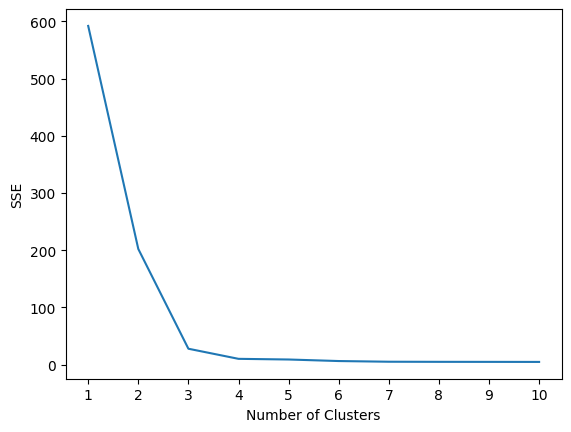

In [ ]:
#Performs elbow method to determine initial number of clusters
kmeans_kwargs = {
"init": "random",
"n_init": 10,
"random_state": 1,
}

sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)

#visualizes results
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

Using the graph generated from the elbow method, we will perform the k-means algorithm starting at 3 clusters.

In [ ]:
#Performing k-means with an initial 3 clusters
kmeans = KMeans(init="random", n_clusters=3, n_init=10, random_state=1)

kmeans.fit(scaled_df)

kmeans.labels_

array([2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

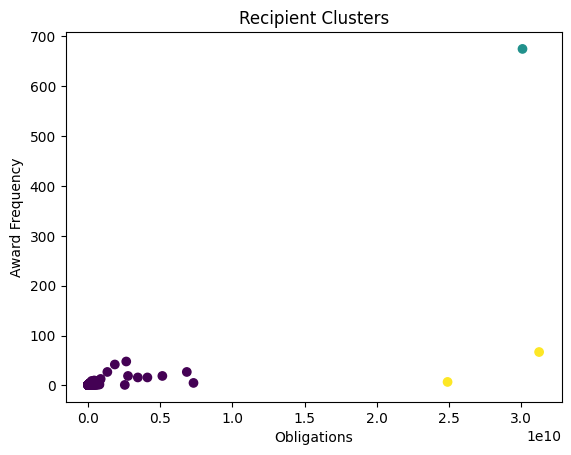

In [ ]:
#Visualizes results onn scatter plot
plt.scatter(Obligations, awardAmount, c=kmeans.labels_)
plt.title('Recipient Clusters')
plt.xlabel('Obligations')
plt.ylabel('Award Frequency')
plt.show()


Based on the results of clustering, only the largest three recipients ended up in their own clusters away from the largest cluster. While this could make sense, seeing as the majority of the recipients have received 5 or less transactions, it makes recipients in the largest cluster indistinguishable. Because of this, we will perform k-means again, this time with 5 clusters, which should divide the largest group into more distinguishable categories.

In [ ]:
#Performing k-means with an initial 5 clusters
kmeans = KMeans(init="random", n_clusters=5, n_init=10, random_state=1)

kmeans.fit(scaled_df)

kmeans.labels_

array([2, 0, 0, 4, 3, 3, 3, 3, 3, 3, 3, 3, 0, 4, 4, 3, 3, 4, 3, 3, 3, 3,
       4, 3, 3, 3, 2, 4, 4, 4, 3, 4, 3, 3, 4, 3, 3, 3, 4, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 4, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 0, 3, 0, 3, 3, 4, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 4, 0, 4, 3, 3, 4, 3, 3, 3, 3, 4,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3], dtype=int32)

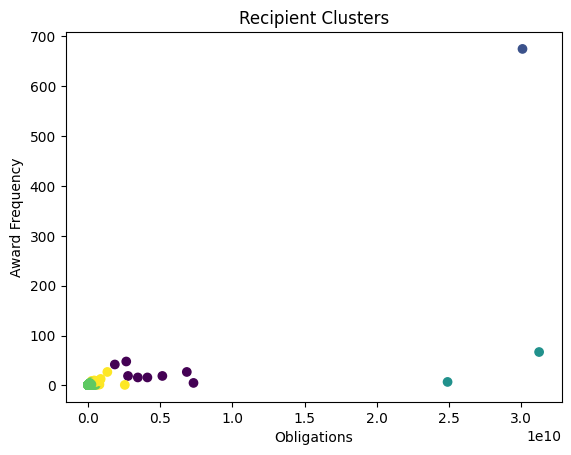

In [ ]:
#Visualizes results onn scatter plot
plt.scatter(Obligations, awardAmount, c=kmeans.labels_)
plt.title('Recipient Clusters')
plt.xlabel('Obligations')
plt.ylabel('Award Frequency')
plt.show()


Now we have more distinguishable groups to examine and interpret. To further visualize these results, we will add the cluster number to the previously generated table.

In [ ]:
#Adds cluster number to the first list that includes the recipient name so we can see what recipient belongs to what cluster
df['cluster'] = kmeans.labels_
display(df)

,Recipients,Obligations,awardAmount,cluster
0,GEORGIA DEPARTMENT OF COMMUNITY HEALTH,2.490330e+10,7,2
1,DEPARTMENT OF EARLY CARE & LEARNING GEORGIA,4.119591e+09,16,0
2,DEPARTMENT OF HUMAN SERVICES,5.154936e+09,19,0
3,DEPARTMENT OF BEHAVIORAL HEALTH AND DEVELOPMEN...,4.366186e+08,10,4
4,VERIZON BUSINESS NETWORK SERVICES LLC,2.324187e+08,2,3
...,...,...,...,...
291,"HEALTH EDUCATION, ASSESSMENT AND LEADERSHIP, I...",2.029535e+07,1,3
292,COUNTY OF CHATHAM,2.024853e+07,1,3
293,"OCONEE VALLEY HEALTHCARE, INC.",2.017566e+07,1,3
294,"J.C. LEWIS PRIMARY HEALTHCARE CENTER, INC.",2.009257e+07,1,3


### Results

The results show five distinct groups of recipients:

Group 0 is made up of seven recipients, most of which are state level departments. This category is defined due to the large number of transactions made to these departments, which makes sense since the state departments further distribute the funds to other local recipients. This group receives a large number of transactions and dollars compared to the rest of the recipients, however there are three recipients who receive far more than these seven recipients.

Group 1 is represented by "Multiple Recipients", which makes up those protected individuals funded by social programs from entities like the Social Security Administration. These individuals collectively make up the recipient with the largest number of awards, and one of the largest amounts of money.

Group 2 houses Lockheed Martin Corp and the Georgia Department of Community Health, both of which are the other two highest recipients of federal funds. They both received less than 100 contracts over the original threshold of 20,000,000, and therefore do not join group 1 with the multiple recipients of social funds, but still receive enough to create their own category. What is surprising is that Lockheed Martin receives more federal funds than the individuals on social programs. This is an interesting metric that could be interpreted many ways, however without comparing this metric to other fiscal years, it is hard to tell if this is coincidence or not.

Group 3 is the largest and broadest category of recipients. These are the smaller businesses who have received less than 10 contracts, and do not receive as much funding as the rest of the recipients. Most of these recipients have only received 1 transaction, and were pruned from the list of frequent sets done by association. These are the recipients who most likely do not operate mostly on federal funds, however have received grants for specific projects. This category also houses some universities and state departments who have received a minimal amount of contracts compared to their like recipients, and therefore did not make the category with them.

Group 4 is a miscellaneous category. These are recipients who have either received a large amount of funding compared to the low amount of transactions they have received, such as Peraton Inc., or have a low amount of federal funding compared to the high amount of contracts they have received, such as Emory University. There are no real connecting features that define these recipients together, however they appear to be either state departments or universities who didn't receive enough to be in Group 0, or businesses who received too much to be in Group 3.

# Updated Interpretations

After performing apriori under several conditions, as well as comparing it to k-means results, we have clear answers to our discovery questions.

First we asked "What combinations of awarding agencies, recipients, and award types frequently occur in different sized regions in Georgia?" We found that larger regions generally hold the largest state government programs, military industries, and universities that receive the majority of federal funding. Furthermore, we found that the majority of frequent recipients across the board only co-occur exclusively with one agency, and those who co-occur with multiple agencies do not receive many transactions. Smaller regions are less likely to receive funding from anywhere other than social security. While some of these findings are surprising to see visualized, they are not out of the ordinary. 

Second, we asked "What natural groupings can be found among federal funding recipients based on the characteristics of their transactions?" The largest found group of recipients is the group of small businesses who receive less than 10 transactions, who most likely receive sparing transactions for specific purposes. On the other side of the spectrum is the group of state facilities who receive the majority of funding and receive a frequent amount of transactions. Beyond this is two groups, one held exclusively by individuals who receive social programs, and one held by Lockheed Martin and the Georgia Department of Community Health, who are also in the top three recipients in transactions and funding, however they do not receive as many transactions as the collective of individuals on social programs. Lastly, there is a miscellaneous category for larger firms who did not receive enough to be in the state firm category, or smaller businesses who received too much to be in their respective category.

For the comparison goals listed in the M3 milestone, apriori demonstrated more surprising results when the frequent sets were made up of a smaller amount of variables. This means that it is more effective to examine one parameter based on other variables rather than examining combinations of several variables. With the sheer quantity of transactions, and the sheer variety in transaction details, examining one of those details alone shows more focus and reveals a lot more than the broader scope. This is confirmed once more in the results of k-means, which examined only the characteristics that define the recipient in the given transaction. While the results were not out of the ordinary, it is surprising to see the natural clustering of these recipients and how they compare to each other rather than their individual relations with other qualitative variables. 

# Updated Limitations

Under the new parameters, the limitations of our preset transaction characteristic thresholds have begun to appear. We chose to only examine transactions with a minimum obligation of 20,000,000, a decision to reduce dimensionality and make the data more manageable in the given time and resources. This may help in those regards, however there is a chance that this limitation has skewed the data in major ways. For example, there is a significant chance that some of the smaller businesses receive more transactions than is present in the current data set that are not being accounted for. In addition to this, we mentioned that Lockheed Martin received more total obligations than the collective of individuals on social programs. This could be a real possibility given the state of current events in regards to military action, however there is no way of telling if this is a legitimate metric without the total picture of transactions. 

We also chose to limit out scope to fiscal year 2025, a decision made for reducing dimensionality, and also to limit the amount of skewed data that may come from any abnormal fiscal years. However, this only increases the amount of trivial data, for without a direct comparison to other fiscal years, it is hard to validate the results of our study. Furthermore, without comparing the results to another state, we cannot tell how surprising our results are. However, since the results of this study are surprising, but not out of the ordinary, they can be used as a direct comparison to other states or other fiscal years to judge the surprising nature of other data sets.

# Plans for M4

Every planned technique has been fully implemented, however the code and visuals for the notebook needs to be polished as a whole within the M4 time period. With large tables being the biggest and most relevant visuals, I plan to discover ways to strengthen the quality of these visuals. Furthermore, I also want to add anomaly detection to the study. While the preprocessing portion of the study revealed that there were no real defining characteristics of transactions flagged as an outlier, I want to perform an anomaly detection to confirm this to be the case. I also want to collect data sets from different fiscal years in Georgia, then perform k-means clustering on them in order to directly compare results between each fiscal year, with the goal of seeing how normal or abnormal our current results are. While we have clear answers to our discovery questions, these final tasks should help validate our findings and interpretations.